# Laboratorio 7 — Spark MLlib
**CC3066 Data Science — Universidad del Valle de Guatemala — Semestre II 2026**

Análisis de salarios de personas asalariadas con la Encuesta Nacional de Empleo e Ingresos Continua (ENEIC) del INE.

| Rol | Archivo(s) |
|---|---|
| Entrenamiento (desarrollo) | 2025T1, 2025T2, 2025T3 |
| Validación (luego se suma al entrenamiento final) | 2025T4 |
| Prueba final | 2026T1 |

**Preguntas que guían el análisis**
1. ¿Qué perfiles de trabajadores asalariados se pueden identificar según edad, antigüedad y jornada habitual?
2. ¿Qué tan bien se puede estimar el salario mensual con características personales y laborales observadas?

> Todos los resultados son **no ponderados**: describen los registros analizados, no son estimaciones oficiales de la población guatemalteca. Las asociaciones encontradas no implican causalidad.

**Cómo ejecutar:** `docker compose up -d` en la raíz del repositorio y abrir `http://localhost:8888`. El notebook corre de principio a fin (*Restart & Run All*). La primera ejecución convierte los Excel a Parquet (~6 min); las siguientes reutilizan esos Parquet crudos salvo que `FORZAR_CONVERSION = True`.

## 0. Configuración del entorno

In [1]:
import json
import shutil
import time
from functools import reduce
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from openpyxl import load_workbook

from pyspark.sql import SparkSession, functions as F, types as T
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import VectorAssembler, StandardScaler, StringIndexer, OneHotEncoder
from pyspark.ml.stat import Correlation
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator, RegressionEvaluator
from pyspark.ml.regression import LinearRegression, RandomForestRegressor

spark = (
    SparkSession.builder
    .appName("Lab7-ENEIC-SparkMLlib")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")
print("Spark", spark.version)

SEED = 42
FORZAR_CONVERSION = False   # True para volver a leer los Excel aunque ya exista el Parquet crudo

BASE = Path.cwd()
RAW_DIR = BASE / "data" / "raw" / "personas"
DICC_DIR = BASE / "data" / "diccionarios"
PROC_DIR = BASE / "data" / "processed"
RAW_PARQUET_DIR = PROC_DIR / "raw"
MODELS_DIR = BASE / "models"
for d in (RAW_PARQUET_DIR, MODELS_DIR):
    d.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

FIG_DIR = BASE / "figures"
FIG_DIR.mkdir(exist_ok=True)

def guardar_fig(nombre, fig=None):
    (fig or plt.gcf()).savefig(FIG_DIR / f"{nombre}.png", dpi=150, bbox_inches="tight")


Spark 3.5.0


### Archivos y variables

Cada archivo se identifica por su **procedencia** (el corte publicado por el INE), no por la columna `TRIMESTRE`: en 2025T2 hay 175 registros con `TRIMESTRE = 2`, así que restar uno a esa columna no produce el trimestre calendario correcto.

In [2]:
ARCHIVOS = pd.DataFrame(
    [
        ("Personas_ENEIC_T1_2025.xlsx",                "Diccionario_Personas_ENEIC_I-2025.xlsx",  "2025T1", 2025, 1, "entrenamiento"),
        ("Personas-ENEIC-T2-2025.xlsx",                "Diccionario_Personas_ENEIC_II-2025.xlsx", "2025T2", 2025, 2, "entrenamiento"),
        ("Base-de-datos-Personas-ENEIC-III-2025.xlsx", "Diccionario-Personas-ENEIC-III-2025.xlsx", "2025T3", 2025, 3, "entrenamiento"),
        ("Base-de-datos-Personas-ENEIC-IV-2025.xlsx",  "Diccionario-Personas-ENEIC-IV-2025.xlsx",  "2025T4", 2025, 4, "validacion"),
        ("Base-de-datos-Personas-ENEIC-I-2026.xlsx",   "Diccionario-Personas-ENEIC-I-2026.xlsx",   "2026T1", 2026, 1, "prueba"),
    ],
    columns=["archivo_origen", "diccionario", "periodo_archivo", "anio_archivo", "trimestre_calendario", "rol"],
)
PERIODOS_2025 = ["2025T1", "2025T2", "2025T3", "2025T4"]
PERIODO_TEST = "2026T1"

# Columnas originales requeridas
COLS_NUMERICAS = ["P05D01", "P02A03", "P05C07A", "P05C07B", "P05H01A", "OCUPADOS",
                  "NUM_HOGAR", "NUM_PERSONA", "FACTOR", "ANIO", "TRIMESTRE"]
COLS_CODIGO = ["P03A03A", "P05C16", "DOMINIO"]
COLS_ORIGINALES = COLS_NUMERICAS + COLS_CODIGO

# Nombre analítico de cada variable original
NOMBRES = {
    "P05D01": "salario_mensual", "P02A03": "edad", "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses", "P05H01A": "horas_semanales", "P03A03A": "nivel_educativo_cod",
    "P05C16": "categoria_ocupacional_cod", "DOMINIO": "dominio_cod", "OCUPADOS": "ocupado",
}
ARCHIVOS

,archivo_origen,diccionario,periodo_archivo,anio_archivo,trimestre_calendario,rol
0,Personas_ENEIC_T1_2025.xlsx,Diccionario_Personas_ENEIC_I-2025.xlsx,2025T1,2025,1,entrenamiento
1,Personas-ENEIC-T2-2025.xlsx,Diccionario_Personas_ENEIC_II-2025.xlsx,2025T2,2025,2,entrenamiento
2,Base-de-datos-Personas-ENEIC-III-2025.xlsx,Diccionario-Personas-ENEIC-III-2025.xlsx,2025T3,2025,3,entrenamiento
3,Base-de-datos-Personas-ENEIC-IV-2025.xlsx,Diccionario-Personas-ENEIC-IV-2025.xlsx,2025T4,2025,4,validacion
4,Base-de-datos-Personas-ENEIC-I-2026.xlsx,Diccionario-Personas-ENEIC-I-2026.xlsx,2026T1,2026,1,prueba


## 1. Carga, armonización y calidad de datos

### 1.1 Conversión de Excel a Parquet (archivo por archivo)

Spark no lee Excel de forma nativa. Cada archivo se lee con pandas/openpyxl **uno a la vez**, seleccionando las columnas **por nombre**. Luego se homologan los tipos y se convierte a un DataFrame de Spark con **esquema explícito** para guardarlo en Parquet.

- **Variables numéricas:** se convierten a `double`. Se cuentan los valores que no se pudieron convertir.
- **Códigos categóricos:** se normalizan a texto canónico (`2`, `2.0` y `'2 '` se convierten en `'2'`). En 2025T2 varios códigos vienen como texto y en los demás archivos vienen como número.

In [3]:
def normalizar_codigo(v):
    # Representación canónica de un código: '2', 2, 2.0 y ' 2 ' -> '2'. Texto no numérico se conserva en mayúsculas.
    if v is None or (isinstance(v, float) and np.isnan(v)):
        return None
    s = str(v).strip()
    if s == "":
        return None
    try:
        f = float(s)
        if np.isfinite(f) and f.is_integer():
            return str(int(f))
        return s
    except ValueError:
        return s.upper()


def a_numero(serie):
    # Convierte a float64; devuelve también cuántos valores no nulos no fueron convertibles.
    s = serie.map(lambda v: v.strip() if isinstance(v, str) else v).replace("", np.nan)
    num = pd.to_numeric(s, errors="coerce").astype("float64")
    return num, int((s.notna() & num.isna()).sum())


SCHEMA_CRUDO = T.StructType(
    [T.StructField(c, T.DoubleType(), True) for c in COLS_NUMERICAS]
    + [T.StructField(c, T.StringType(), True) for c in COLS_CODIGO]
    + [
        T.StructField("archivo_origen", T.StringType(), False),
        T.StructField("periodo_archivo", T.StringType(), False),
        T.StructField("anio_archivo", T.IntegerType(), False),
        T.StructField("trimestre_calendario", T.IntegerType(), False),
    ]
)


def convertir_archivo(fila):
    ruta = RAW_DIR / fila.archivo_origen
    wb = load_workbook(ruta, read_only=True)
    encabezado = list(next(wb.worksheets[0].iter_rows(max_row=1, values_only=True)))
    hoja = wb.sheetnames[0]
    wb.close()

    pdf = pd.read_excel(ruta, sheet_name=0, usecols=COLS_ORIGINALES, dtype=object, engine="openpyxl")
    log = {"periodo_archivo": fila.periodo_archivo, "hoja": hoja,
           "filas": len(pdf), "columnas_originales": len(encabezado),
           "tipos_originales": {}, "no_convertibles": {}}
    for c in COLS_ORIGINALES:
        tipos = pdf[c].dropna().map(lambda v: type(v).__name__).value_counts().to_dict()
        log["tipos_originales"][c] = tipos
        if c in COLS_NUMERICAS:
            pdf[c], log["no_convertibles"][c] = a_numero(pdf[c])
        else:
            pdf[c] = pdf[c].map(normalizar_codigo)

    pdf["archivo_origen"] = fila.archivo_origen
    pdf["periodo_archivo"] = fila.periodo_archivo
    pdf["anio_archivo"] = int(fila.anio_archivo)
    pdf["trimestre_calendario"] = int(fila.trimestre_calendario)
    pdf = pdf[[f.name for f in SCHEMA_CRUDO.fields]]
    # NaN de pandas -> null de Spark
    pdf = pdf.astype(object).where(pdf.notna(), None)

    sdf = spark.createDataFrame(pdf, schema=SCHEMA_CRUDO)
    sdf.write.mode("overwrite").parquet(str(RAW_PARQUET_DIR / f"{fila.periodo_archivo}.parquet"))
    return log, encabezado


RUTA_LOG = RAW_PARQUET_DIR / "log_conversion.json"
logs = json.loads(RUTA_LOG.read_text(encoding="utf-8")) if RUTA_LOG.exists() else {}
for fila in ARCHIVOS.itertuples():
    destino = RAW_PARQUET_DIR / f"{fila.periodo_archivo}.parquet"
    if destino.exists() and fila.periodo_archivo in logs and not FORZAR_CONVERSION:
        print(f"{fila.periodo_archivo}: Parquet crudo ya existe, se reutiliza")
        continue
    t0 = time.time()
    log, encabezado = convertir_archivo(fila)
    logs[fila.periodo_archivo] = {**log, "encabezado": encabezado}
    print(f"{fila.periodo_archivo}: {log['filas']:,} filas x {log['columnas_originales']} columnas convertidas en {time.time() - t0:.0f} s")
_ = RUTA_LOG.write_text(json.dumps(logs, ensure_ascii=False, indent=1), encoding="utf-8")

2025T1: Parquet crudo ya existe, se reutiliza
2025T2: Parquet crudo ya existe, se reutiliza
2025T3: Parquet crudo ya existe, se reutiliza
2025T4: Parquet crudo ya existe, se reutiliza
2026T1: Parquet crudo ya existe, se reutiliza


**Estructura de los archivos originales y heterogeneidad de tipos.** La tabla muestra, por archivo, el tipo Python con el que llegó cada código categórico y la posición de algunas columnas clave.

In [4]:
estructura = pd.DataFrame([
    {
        "periodo_archivo": p,
        "hoja": logs[p]["hoja"],
        "filas": logs[p]["filas"],
        "columnas": logs[p]["columnas_originales"],
        **{f"pos_{c}": logs[p]["encabezado"].index(c) + 1 for c in ["P05C16", "P05D01", "P05H01A", "OCUPADOS"]},
        **{f"tipo_{c}": "/".join(sorted(logs[p]["tipos_originales"][c])) for c in ["P03A03A", "P05C16", "DOMINIO", "P05C07B"]},
        "no_convertibles": sum(logs[p]["no_convertibles"].values()),
    }
    for p in ARCHIVOS.periodo_archivo
])
display(estructura)

cols_base = logs["2025T1"]["encabezado"]
cols_iv = logs["2025T4"]["encabezado"]
extra_iv = [c for c in cols_iv if c not in cols_base]
misma_posicion = sum(a == b for a, b in zip(cols_base, cols_iv))
print(f"IV-2025 tiene {len(extra_iv)} columnas que no existen en I-2025: {extra_iv}")
print(f"Solo {misma_posicion} de {len(cols_base)} columnas de I-2025 coinciden en la misma posición en IV-2025")
print("¿I, II, III 2025 y I 2026 tienen el mismo encabezado?:",
      all(logs[p]["encabezado"] == cols_base for p in ["2025T2", "2025T3", "2026T1"]))

,periodo_archivo,hoja,filas,columnas,pos_P05C16,pos_P05D01,pos_P05H01A,pos_OCUPADOS,tipo_P03A03A,tipo_P05C16,tipo_DOMINIO,tipo_P05C07B,no_convertibles
0,2025T1,Personas_ENEIC_T1_2025,51588,270,88,105,218,266,int,int,int,int,0
1,2025T2,Personas ENEIC T2-2025,51167,270,88,105,218,266,str,str,str,str,0
2,2025T3,Personas ENEIC T3-2025,51583,270,88,105,218,266,int,int,int,int,0
3,2025T4,Base de datos Personas ENEIC IV,49338,302,81,98,208,298,int,int,int,int,0
4,2026T1,Personas_ENEIC_T1-2026,49843,270,88,105,218,266,int,int,int,int,0


IV-2025 tiene 42 columnas que no existen en I-2025: ['P07A01A', 'P07A01B', 'P07A01C', 'P07A02A', 'P07A02B', 'P07A02C', 'P07A03A', 'P07A03B', 'P07A03C', 'P07A04A', 'P07A04B', 'P07A04C', 'P08A01A', 'P08A01B', 'P08A01C', 'P08A02A', 'P08A02B', 'P08A02C', 'P08B01A', 'P08B01B', 'P08B01C', 'P08B02A', 'P08B02B', 'P08B02C', 'P08C01A', 'P08C01B', 'P08C01C', 'P08D01A', 'P08D01B', 'P08D01C', 'P08E01A', 'P08E01B', 'P08E01C', 'P08E02A', 'P08E02B', 'P08E02C', 'P08E03A', 'P08E03B', 'P08E03C', 'P08F01A', 'P08F01B', 'P08F01C']
Solo 7 de 270 columnas de I-2025 coinciden en la misma posición en IV-2025
¿I, II, III 2025 y I 2026 tienen el mismo encabezado?: True


### 1.2 Unión de los archivos de 2025 con `unionByName`

In [5]:
crudos = {p: spark.read.parquet(str(RAW_PARQUET_DIR / f"{p}.parquet")) for p in ARCHIVOS.periodo_archivo}
crudo_2025 = reduce(lambda a, b: a.unionByName(b), [crudos[p] for p in PERIODOS_2025]).cache()
crudo_2026 = crudos[PERIODO_TEST].cache()

print("Registros 2025:", f"{crudo_2025.count():,}", "| Registros 2026:", f"{crudo_2026.count():,}")
crudo_2025.printSchema()

Registros 2025: 203,676 | Registros 2026: 49,843
root
 |-- P05D01: double (nullable = true)
 |-- P02A03: double (nullable = true)
 |-- P05C07A: double (nullable = true)
 |-- P05C07B: double (nullable = true)
 |-- P05H01A: double (nullable = true)
 |-- OCUPADOS: double (nullable = true)
 |-- NUM_HOGAR: double (nullable = true)
 |-- NUM_PERSONA: double (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- ANIO: double (nullable = true)
 |-- TRIMESTRE: double (nullable = true)
 |-- P03A03A: string (nullable = true)
 |-- P05C16: string (nullable = true)
 |-- DOMINIO: string (nullable = true)
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)



### 1.3 Validación de códigos contra los diccionarios

Se lee la sección *Valores de variable* del diccionario de cada archivo y se compara la codificación de las variables categóricas entre periodos.

In [6]:
def leer_valores_diccionario(ruta, variables):
    d = pd.read_excel(ruta, sheet_name=0, header=None, dtype=str)
    inicio = d.index[d[0].astype(str).str.strip().str.lower().str.startswith("valores de variable")][0]
    v = d.iloc[inicio + 2:, :3].copy()
    v.columns = ["variable", "codigo", "etiqueta"]
    v["variable"] = v["variable"].ffill().str.strip()
    v = v[v["variable"].isin(variables) & v["codigo"].notna()]
    v["codigo"] = v["codigo"].map(normalizar_codigo)
    v["etiqueta"] = v["etiqueta"].str.strip().str.rstrip("?")
    return v


VARS_DICC = ["P03A03A", "P05C16", "DOMINIO", "OCUPADOS", "P05C07B"]
diccionarios = {
    fila.periodo_archivo: leer_valores_diccionario(DICC_DIR / fila.diccionario, VARS_DICC)
    for fila in ARCHIVOS.itertuples()
}
ref = diccionarios["2025T1"].reset_index(drop=True)
iguales = {p: d.reset_index(drop=True).equals(ref) for p, d in diccionarios.items()}
print("¿Codificación idéntica a la de 2025T1?", iguales)
assert all(iguales.values()), "Los diccionarios difieren: revisar antes de mapear"

MAPA = {var: dict(zip(g["codigo"], g["etiqueta"])) for var, g in ref.groupby("variable")}
for var in ["P03A03A", "P05C16", "DOMINIO"]:
    print(var, MAPA[var])

¿Codificación idéntica a la de 2025T1? {'2025T1': True, '2025T2': True, '2025T3': True, '2025T4': True, '2026T1': True}
P03A03A {'0': 'NINGUNO', '1': 'PREPRIMARIA', '2': 'PRIMARIA', '3': 'BÁSICO', '4': 'DIVERSIFICADO', '5': 'SUPERIOR', '6': 'MAESTRÍA', '7': 'DOCTORADO'}
P05C16 {'1': 'Empleado de gobierno', '2': 'Empleado de empresa privada', '3': 'Empleado jornalero o peón', '4': 'Del servicio doméstico', '5': 'Trabajador por cuenta propia NO agrícola', '6': 'Patrón empleador (a) socio (a) NO agrícola', '7': 'Trabajador por cuenta propia agrícola', '8': 'Patrón empleador (a) socio (a) agrícola', '9': 'Trabajador No remunerado'}
DOMINIO {'1': 'Urbano Metropolitano', '2': 'Resto Urbano', '3': 'Rural Nacional'}


In [7]:
# Códigos observados que no aparecen en el diccionario (antes de filtrar)
crudo_todo = crudo_2025.unionByName(crudo_2026)
filas = []
for var in ["P03A03A", "P05C16", "DOMINIO"]:
    obs = crudo_todo.groupBy("periodo_archivo", var).count().toPandas()
    obs["en_diccionario"] = obs[var].isin(list(MAPA[var]))
    obs["estado"] = np.where(obs[var].isna(), "ausente", np.where(obs["en_diccionario"], "válido", "no reconocido"))
    filas.append(obs.groupby(["periodo_archivo", "estado"])["count"].sum().unstack(fill_value=0).assign(variable=var))
validacion_codigos = pd.concat(filas).reset_index().set_index(["variable", "periodo_archivo"]).fillna(0).astype(int)
validacion_codigos

estado                    ausente  válido
variable periodo_archivo                 
P03A03A  2025T1              6928   44660
         2025T2              6678   44489
         2025T3              6548   45035
         2025T4              6190   43148
         2026T1              6011   43832
P05C16   2025T1             29315   22273
         2025T2             28824   22343
         2025T3             29210   22373
         2025T4             28105   21233
         2026T1             28109   21734
DOMINIO  2025T1                 0   51588
         2025T2                 0   51167
         2025T3                 0   51583
         2025T4                 0   49338
         2026T1                 0   49843

### 1.4 Variables analíticas

- Los códigos válidos se traducen a su etiqueta. Los ausentes o no reconocidos quedan como **`DESCONOCIDO`**, nunca como cero.
- En educación, el código `0` significa *NINGUNO* y es una categoría válida.
- `antiguedad = antiguedad_anios + antiguedad_meses / 12` (en años).

In [8]:
def mapa_spark(diccionario):
    return F.create_map(*[F.lit(x) for kv in diccionario.items() for x in kv])


ETIQ_EDU = {k: f"{k} {v.capitalize()}" for k, v in MAPA["P03A03A"].items()}   # '2 Primaria' conserva el orden
ETIQ_CAT = MAPA["P05C16"]
ETIQ_DOM = MAPA["DOMINIO"]
ORDEN_EDU = [ETIQ_EDU[k] for k in sorted(ETIQ_EDU, key=int)] + ["DESCONOCIDO"]
ORDEN_DOM = [ETIQ_DOM[k] for k in sorted(ETIQ_DOM, key=int)] + ["DESCONOCIDO"]


def variables_analiticas(df):
    # Se renombra (no se copia): Spark no distingue mayúsculas, así que 'dominio' y 'DOMINIO' serían la misma columna
    for original, nuevo in NOMBRES.items():
        df = df.withColumnRenamed(original, nuevo)
    return (
        df.withColumn("antiguedad", F.col("antiguedad_anios") + F.col("antiguedad_meses") / 12)
        .withColumn("nivel_educativo", F.coalesce(mapa_spark(ETIQ_EDU)[F.col("nivel_educativo_cod")], F.lit("DESCONOCIDO")))
        .withColumn("categoria_ocupacional", F.coalesce(mapa_spark(ETIQ_CAT)[F.col("categoria_ocupacional_cod")], F.lit("DESCONOCIDO")))
        .withColumn("dominio", F.coalesce(mapa_spark(ETIQ_DOM)[F.col("dominio_cod")], F.lit("DESCONOCIDO")))
    )


base_2025 = variables_analiticas(crudo_2025)
base_2026 = variables_analiticas(crudo_2026)

### 1.5 Faltantes por variable (antes de filtrar)

Se considera faltante un valor nulo o `NaN`. Casi todos los faltantes de las variables laborales se deben al **flujo del cuestionario**: las preguntas de empleo solo se hacen a personas ocupadas y las de salario solo a asalariados. Por eso los porcentajes altos son esperados y no indican errores de captura.

In [9]:
def tabla_faltantes(df, columnas):
    tipos = dict(df.dtypes)
    exprs = []
    for c in columnas:
        falta = F.col(c).isNull()
        if tipos[c] in ("double", "float"):
            falta = falta | F.isnan(F.col(c))
        exprs.append(F.sum(falta.cast("int")).alias(c))
    agg = df.groupBy("periodo_archivo").agg(F.count(F.lit(1)).alias("registros"), *exprs).toPandas()
    agg = agg.set_index("periodo_archivo").sort_index()
    agg.loc["Total 2025"] = agg.loc[[p for p in agg.index if p.startswith("2025")]].sum()
    n = agg.pop("registros")
    tabla = pd.concat({"faltantes": agg.T, "%": (agg.div(n, axis=0) * 100).T}, axis=1)
    return tabla.swaplevel(axis=1).sort_index(axis=1, level=0, sort_remaining=False)


faltantes = tabla_faltantes(crudo_todo, COLS_ORIGINALES)
faltantes.index = [f"{c} ({NOMBRES.get(c, c)})" for c in faltantes.index]
faltantes.style.format(lambda v: f"{v:,.1f}" if isinstance(v, float) and v % 1 else f"{v:,.0f}")

### 1.6 Filtros de la población analítica

Los criterios se aplican **siempre en el mismo orden**. A cada registro se le asigna el **primer** criterio que incumple, así que cada exclusión se cuenta una sola vez. Una condición que no se puede evaluar (por ejemplo, horas nulas) cuenta como incumplida. El salario no se imputa.

| Paso | Criterio |
|---|---|
| 1 | Edad finita y ≥ 15 |
| 2 | Ocupado (`OCUPADOS = 1`) |
| 3 | Asalariado (`P05C16` ∈ {1, 2, 3, 4}) |
| 4 | Salario (`P05D01`) numérico, finito y > 0 |
| 5 | Antigüedad evaluable: años ≥ 0 y meses enteros entre 0 y 11 |
| 6 | Antigüedad calculada ≤ edad |
| 7 | 0 < horas habituales ≤ 168 |

In [10]:
def finito(c):
    return F.col(c).isNotNull() & ~F.isnan(F.col(c)) & (F.abs(F.col(c)) < F.lit(float("inf")))


CRITERIOS = [
    ("1 edad < 15 o no válida", finito("edad") & (F.col("edad") >= 15)),
    ("2 no ocupado", F.col("ocupado") == 1),
    ("3 no asalariado", F.col("categoria_ocupacional_cod").isin("1", "2", "3", "4")),
    ("4 salario no válido o <= 0", finito("salario_mensual") & (F.col("salario_mensual") > 0)),
    ("5 antigüedad no evaluable", finito("antiguedad_anios") & (F.col("antiguedad_anios") >= 0)
        & finito("antiguedad_meses") & (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
        & F.col("antiguedad_meses").between(0, 11)),
    ("6 antigüedad > edad", F.col("antiguedad") <= F.col("edad")),
    ("7 horas fuera de (0, 168]", finito("horas_semanales") & (F.col("horas_semanales") > 0) & (F.col("horas_semanales") <= 168)),
]
MOTIVOS = [m for m, _ in CRITERIOS]


def marcar_exclusion(df):
    motivo = F.lit(None).cast("string")
    for nombre, cond in reversed(CRITERIOS):
        motivo = F.when(~F.coalesce(cond, F.lit(False)), F.lit(nombre)).otherwise(motivo)
    return df.withColumn("motivo_exclusion", motivo)


marcado = marcar_exclusion(base_2025.unionByName(base_2026)).cache()
conteo = (marcado.groupBy("periodo_archivo").pivot("motivo_exclusion", MOTIVOS).count()
          .join(marcado.groupBy("periodo_archivo").agg(F.count(F.lit(1)).alias("antes"),
                F.sum(F.col("motivo_exclusion").isNull().cast("int")).alias("después")), "periodo_archivo")
          .toPandas().set_index("periodo_archivo").sort_index().fillna(0).astype(int))
conteo = conteo[["antes"] + MOTIVOS + ["después"]]
conteo.loc["Total 2025"] = conteo.loc[PERIODOS_2025].sum()
conteo["% conservado"] = conteo["después"] / conteo["antes"] * 100
conteo

,antes,1 edad < 15 o no válida,2 no ocupado,3 no asalariado,4 salario no válido o <= 0,5 antigüedad no evaluable,6 antigüedad > edad,"7 horas fuera de (0, 168]",después,% conservado
periodo_archivo,,,,,,,,,,
2025T1,51588,16253,13062,8854,0,0,0,0,13419,26.01
2025T2,51167,15882,12942,8851,0,0,0,0,13492,26.37
2025T3,51583,15767,13443,8923,0,0,0,0,13450,26.07
2025T4,49338,14984,13121,8569,0,0,0,0,12664,25.67
2026T1,49843,14803,13306,8476,0,0,0,0,13258,26.60
Total 2025,203676,62886,52568,35197,0,0,0,0,53025,26.03


periodo_archivo,Total 2025,2026T1
original,203676,49843
tras paso 1 edad < 15 o no válida,140790,35040
tras paso 2 no ocupado,88222,21734
tras paso 3 no asalariado,53025,13258
tras paso 4 salario no válido o <= 0,53025,13258
tras paso 5 antigüedad no evaluable,53025,13258
tras paso 6 antigüedad > edad,53025,13258
"tras paso 7 horas fuera de (0, 168]",53025,13258


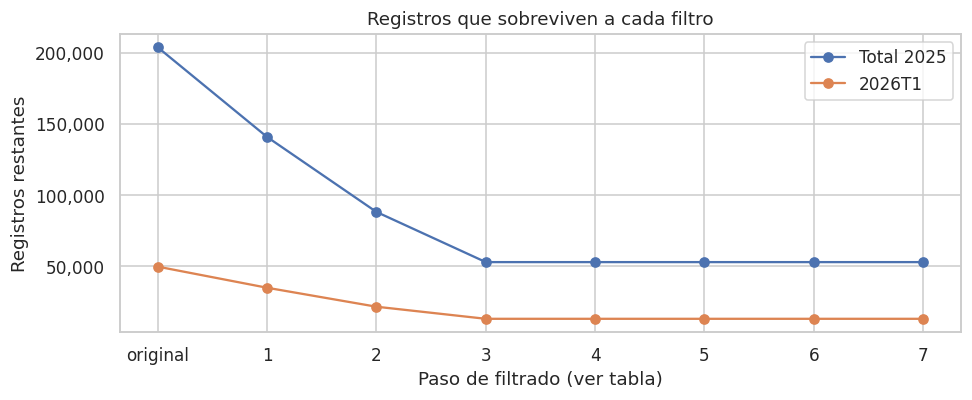

In [11]:
# Registros restantes después de cada paso (acumulado), 2025 vs 2026
restantes = conteo.loc[["Total 2025", PERIODO_TEST], ["antes"] + MOTIVOS].copy()
restantes[MOTIVOS] = restantes["antes"].values[:, None] - restantes[MOTIVOS].cumsum(axis=1)
restantes.columns = ["original"] + [f"tras paso {m}" for m in MOTIVOS]
display(restantes.T)

fig, ax = plt.subplots(figsize=(9, 3.8))
for per, fila in restantes.iterrows():
    ax.plot(range(len(fila)), fila.values, marker="o", label=per)
ax.set_xticks(range(len(restantes.columns)), ["original"] + [m.split(" ", 1)[0] for m in MOTIVOS])
ax.set_xlabel("Paso de filtrado (ver tabla)")
ax.set_ylabel("Registros restantes")
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_title("Registros que sobreviven a cada filtro")
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación de los filtros**
- Los tres primeros pasos concentran **todas** las exclusiones. En 2025 se retiran 62,886 menores de 15 años, 52,568 personas no ocupadas y 35,197 ocupados no asalariados (cuenta propia, patronos y trabajadores no remunerados).
- Los pasos 4 a 7 no excluyen ningún registro en ningún archivo. Todos los asalariados ocupados tienen salario positivo, antigüedad evaluable y coherente con la edad, y horas dentro de (0, 168]. Esto sugiere que el INE ya validó estas variables. Aun así, los filtros se mantienen en el código porque son reglas del análisis y se aplican igual a 2026T1.
- La población analítica es de **53,025 registros en 2025** y **13,258 en 2026T1**. Es cerca del 26% de cada archivo, una proporción muy estable entre periodos (25.7%–26.6%).

### 1.7 Unicidad de la clave `periodo_archivo + NUM_HOGAR + NUM_PERSONA`

Se verifica sobre **todos** los registros (antes de filtrar) y sobre la población analítica. No se usa `dropDuplicates()`. Si aparecen claves repetidas, se revisa si son repeticiones exactas o registros en conflicto.

In [12]:
CLAVE = ["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"]

def revisar_unicidad(df, nombre):
    dup = df.groupBy(CLAVE).count().filter("count > 1")
    n_dup = dup.count()
    print(f"{nombre}: {df.count():,} registros, {df.select(CLAVE).distinct().count():,} claves distintas, {n_dup:,} claves repetidas")
    if n_dup:
        cols = [c for c in df.columns if c != "motivo_exclusion"]
        detalle = (df.join(dup.select(CLAVE), CLAVE)
                   .groupBy(CLAVE).agg(F.count(F.lit(1)).alias("filas"),
                                       F.countDistinct(F.struct(*cols)).alias("versiones_distintas"))
                   .withColumn("tipo", F.when(F.col("versiones_distintas") == 1, "repetición exacta").otherwise("conflicto")))
        display(detalle.groupBy("periodo_archivo", "tipo").count().toPandas())
        return detalle
    return None

dup_todos = revisar_unicidad(marcado, "Todos los registros")
dup_analitica = revisar_unicidad(marcado.filter(F.col("motivo_exclusion").isNull()), "Población analítica")

Todos los registros: 253,519 registros, 253,519 claves distintas, 0 claves repetidas


Población analítica: 66,283 registros, 66,283 claves distintas, 0 claves repetidas


In [13]:
# Contexto longitudinal: la misma combinación hogar-persona aparece en varios periodos (rotación del panel)
apariciones = (marcado.filter(F.col("motivo_exclusion").isNull() & F.col("periodo_archivo").startswith("2025"))
               .groupBy("NUM_HOGAR", "NUM_PERSONA").agg(F.countDistinct("periodo_archivo").alias("periodos"))
               .groupBy("periodos").count().orderBy("periodos").toPandas())
apariciones["%"] = apariciones["count"] / apariciones["count"].sum() * 100
apariciones.rename(columns={"count": "combinaciones hogar-persona"})

,periodos,combinaciones hogar-persona,%
0,1,11303,42.32
1,2,7831,29.32
2,3,4240,15.87
3,4,3335,12.49


**Interpretación**
- La combinación `periodo_archivo + NUM_HOGAR + NUM_PERSONA` es **única** en los 253,519 registros originales y en la población analítica. No hay repeticiones exactas ni registros en conflicto, así que no hizo falta eliminar nada.
- En cambio, **sin** el periodo, el 57.7% de las combinaciones hogar-persona de la población analítica de 2025 aparece en más de un trimestre, y el 12.5% en los cuatro. Esto es consistente con el **diseño longitudinal con rotación** de la ENEIC: el número de filas (53,025) no equivale al número de personas distintas.

### 1.8 Conjuntos preparados: esquema, muestra y guardado en Parquet

In [14]:
COLS_FINALES = [
    "archivo_origen", "periodo_archivo", "anio_archivo", "trimestre_calendario", "ANIO", "TRIMESTRE",
    "NUM_HOGAR", "NUM_PERSONA", "FACTOR",
    "salario_mensual", "edad", "antiguedad_anios", "antiguedad_meses", "antiguedad", "horas_semanales",
    "nivel_educativo_cod", "nivel_educativo", "categoria_ocupacional_cod", "categoria_ocupacional",
    "dominio_cod", "dominio", "ocupado",
]
ENTEROS = {"ANIO", "TRIMESTRE", "NUM_HOGAR", "NUM_PERSONA", "ocupado"}
analitica = marcado.filter(F.col("motivo_exclusion").isNull()).select(
    [F.col(c).cast("int").alias(c) if c in ENTEROS else F.col(c) for c in COLS_FINALES])
analitica.filter(F.col("anio_archivo") == 2025).write.mode("overwrite").parquet(str(PROC_DIR / "eneic_2025_preparado.parquet"))
analitica.filter(F.col("periodo_archivo") == PERIODO_TEST).write.mode("overwrite").parquet(str(PROC_DIR / "eneic_2026T1_preparado.parquet"))

# Orden y particionado fijos: KMeans y Random Forest dependen del particionado para su muestreo aleatorio.
# Se reparte por hash de la clave (no por rangos muestreados, que dependen de cómo quedaron los archivos Parquet)
# y se ordena dentro de cada partición, así los resultados son reproducibles entre ejecuciones y máquinas.
def leer_preparado(nombre):
    return spark.read.parquet(str(PROC_DIR / nombre)).repartition(4, *CLAVE).sortWithinPartitions(*CLAVE).cache()

df25 = leer_preparado("eneic_2025_preparado.parquet")
df26 = leer_preparado("eneic_2026T1_preparado.parquet")
print(f"2025 preparado: {df25.count():,} registros | 2026T1 preparado: {df26.count():,} registros")
df25.printSchema()
df25.show(5, truncate=False)

2025 preparado: 53,025 registros | 2026T1 preparado: 13,258 registros
root
 |-- archivo_origen: string (nullable = true)
 |-- periodo_archivo: string (nullable = true)
 |-- anio_archivo: integer (nullable = true)
 |-- trimestre_calendario: integer (nullable = true)
 |-- ANIO: integer (nullable = true)
 |-- TRIMESTRE: integer (nullable = true)
 |-- NUM_HOGAR: integer (nullable = true)
 |-- NUM_PERSONA: integer (nullable = true)
 |-- FACTOR: double (nullable = true)
 |-- salario_mensual: double (nullable = true)
 |-- edad: double (nullable = true)
 |-- antiguedad_anios: double (nullable = true)
 |-- antiguedad_meses: double (nullable = true)
 |-- antiguedad: double (nullable = true)
 |-- horas_semanales: double (nullable = true)
 |-- nivel_educativo_cod: string (nullable = true)
 |-- nivel_educativo: string (nullable = true)
 |-- categoria_ocupacional_cod: string (nullable = true)
 |-- categoria_ocupacional: string (nullable = true)
 |-- dominio_cod: string (nullable = true)
 |-- dominio

+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+------------------+---------------+-------------------+---------------+-------------------------+---------------------------+-----------+--------------------+-------+
|archivo_origen             |periodo_archivo|anio_archivo|trimestre_calendario|ANIO|TRIMESTRE|NUM_HOGAR|NUM_PERSONA|FACTOR|salario_mensual|edad|antiguedad_anios|antiguedad_meses|antiguedad        |horas_semanales|nivel_educativo_cod|nivel_educativo|categoria_ocupacional_cod|categoria_ocupacional      |dominio_cod|dominio             |ocupado|
+---------------------------+---------------+------------+--------------------+----+---------+---------+-----------+------+---------------+----+----------------+----------------+------------------+---------------+-------------------+---------------+-------------------------+---------------------------+-------

In [15]:
# FACTOR (factor de expansión): cuántas personas de la población representa cada registro. NO se usa en el análisis (no ponderado).
(analitica.groupBy("periodo_archivo")
 .agg(F.count(F.lit(1)).alias("registros"), F.sum("FACTOR").alias("suma_FACTOR"), F.mean("FACTOR").alias("FACTOR_medio"),
      (F.sum(F.col("salario_mensual") * F.col("FACTOR")) / F.sum("FACTOR")).alias("salario_medio_ponderado"),
      F.mean("salario_mensual").alias("salario_medio_no_ponderado"))
 .orderBy("periodo_archivo").toPandas())

,periodo_archivo,registros,suma_FACTOR,FACTOR_medio,salario_medio_ponderado,salario_medio_no_ponderado
0,2025T1,13419,"4,715,485.00",351.40,"3,113.28","3,315.63"
1,2025T2,13492,"4,787,795.00",354.86,"3,131.41","3,364.57"
2,2025T3,13450,"4,713,724.00",350.46,"3,189.42","3,469.07"
3,2025T4,12664,"4,722,327.00",372.89,"3,268.76","3,544.57"
4,2026T1,13258,"4,878,412.00",367.96,"3,226.68","3,565.80"


### 1.9 Preguntas

**¿Por qué IV-2025 no puede apilarse por posición con los otros archivos?**
IV-2025 tiene **302 columnas** en lugar de 270. Incluye 42 variables nuevas (bloques `P07A…` y `P08…`) insertadas antes de las variables finales, así que solo 7 de las 270 columnas de I-2025 quedan en la misma posición. Por ejemplo, `P05D01` está en la columna 105 en los demás archivos y en la 98 en IV-2025, y `OCUPADOS` pasa de la 266 a la 298. Un `union` por posición fallaría por el número de columnas o, peor, mezclaría en silencio variables distintas bajo un mismo nombre. Por eso las columnas se seleccionan **por nombre** al leer cada archivo y los DataFrames se unen con `unionByName`.

**¿Qué diferencia hay entre un dato ausente porque la pregunta no corresponde y una respuesta no registrada?**
- *No corresponde:* el flujo del cuestionario salta la pregunta porque no aplica a esa persona. En la tabla de faltantes, horas, antigüedad y `P05C16` faltan en exactamente los mismos registros en que `OCUPADOS` es nulo (56.7%): son personas no ocupadas, a quienes no se les pregunta por su empleo. El salario falta en el 74% porque solo se pregunta a asalariados. La educación falta solo en niños de 0 a 6 años. En `OCUPADOS`, el nulo significa "no ocupado", no un dato perdido. Estos vacíos son información estructural: definen la población y no deben imputarse.
- *No registrada:* la pregunta sí aplicaba, pero no hay respuesta válida (no sabe, no respondió o error de captura). Esto sí es un faltante real y puede introducir sesgo. En nuestros datos, el paso 4 no excluyó a ningún asalariado ocupado, así que no hay asalariados sin salario registrado.

**¿Por qué una persona observada en dos periodos no debe eliminarse como duplicado?**
Cada registro es una observación **persona-periodo**. En otro trimestre la misma persona puede tener otro salario, otras horas u otra antigüedad, y la clave válida incluye `periodo_archivo`. Eliminarla perdería información real y cambiaría la composición de cada trimestre, que ya no representaría el corte publicado. Lo que sí hay que tener presente es que esas observaciones **no son independientes**: parte de las personas de validación (2025T4) y de prueba (2026T1) probablemente también están en entrenamiento, lo que puede hacer la evaluación algo optimista.

**¿Por qué el número de registros filtrados no representa a todos los trabajadores del país?**
1. Es una **muestra**: cada registro representa en promedio a ~350–370 personas (`FACTOR`). Los ~13,000 registros analíticos de cada trimestre representan a unos **4.7–4.9 millones** de asalariados con salario registrado (suma de `FACTOR`). Contar filas no es contar trabajadores.
2. Solo incluye **asalariados con salario positivo**. Deja fuera a trabajadores por cuenta propia, patronos y trabajadores no remunerados, que en 2025 son 35,197 de los 88,222 ocupados de la muestra (~40%).
3. Al apilar trimestres, la misma persona aparece varias veces.
4. El análisis es **no ponderado**: las zonas o grupos sobre- o submuestreados pesan según su número de registros, no según su peso poblacional.

Para estimaciones poblacionales (total de asalariados, salario medio nacional, etc.) habría que ponderar cada registro por `FACTOR` y tomar en cuenta el diseño muestral (estratos y conglomerados) para los errores estándar. La tabla de `FACTOR` muestra por qué importa: el salario medio **ponderado** (Q3,113–Q3,269 según el trimestre) es entre Q200 y Q340 **menor** que el no ponderado (Q3,316–Q3,566). En la muestra están sobrerrepresentados los registros con salarios más altos, que tienen factores de expansión menores.

## 2. Estadística descriptiva y exploración (población analítica 2025)

Las estadísticas se calculan en Spark sobre **todos** los registros elegibles de 2025. Los percentiles son exactos (`percentile`). A pandas solo pasan tablas agregadas.

In [16]:
VARS_NUM = ["salario_mensual", "edad", "antiguedad", "horas_semanales"]

def descriptivos(df, cols):
    filas = []
    for c in cols:
        r = df.agg(
            F.count(c).alias("n"), F.mean(c).alias("media"), F.stddev(c).alias("desv_std"),
            F.min(c).alias("min"), F.max(c).alias("max"),
            F.expr(f"percentile({c}, array(0.25, 0.5, 0.75, 0.95))").alias("p"),
            F.skewness(c).alias("asimetria"),
        ).first()
        filas.append({"variable": c, "n": r["n"], "media": r["media"], "mediana": r["p"][1],
                      "desv_std": r["desv_std"], "min": r["min"], "p25": r["p"][0], "p75": r["p"][2],
                      "p95": r["p"][3], "max": r["max"], "asimetria": r["asimetria"]})
    return pd.DataFrame(filas).set_index("variable")

desc25 = descriptivos(df25, VARS_NUM)
desc25

,n,media,mediana,desv_std,min,p25,p75,p95,max,asimetria
variable,,,,,,,,,,
salario_mensual,53025,"3,421.68","3,000.00","2,902.11",1.00,"1,800.00","4,000.00","8,000.00","99,000.00",6.00
edad,53025,35.19,33.00,13.52,15.00,24.00,44.00,61.00,89.00,0.74
antiguedad,53025,5.56,2.00,7.83,0.00,0.50,7.00,22.00,70.00,2.40
horas_semanales,53025,46.31,45.00,18.63,1.00,40.00,55.00,80.00,126.00,0.59


### 2.1 Distribución de registros por categoría ocupacional, nivel educativo y dominio

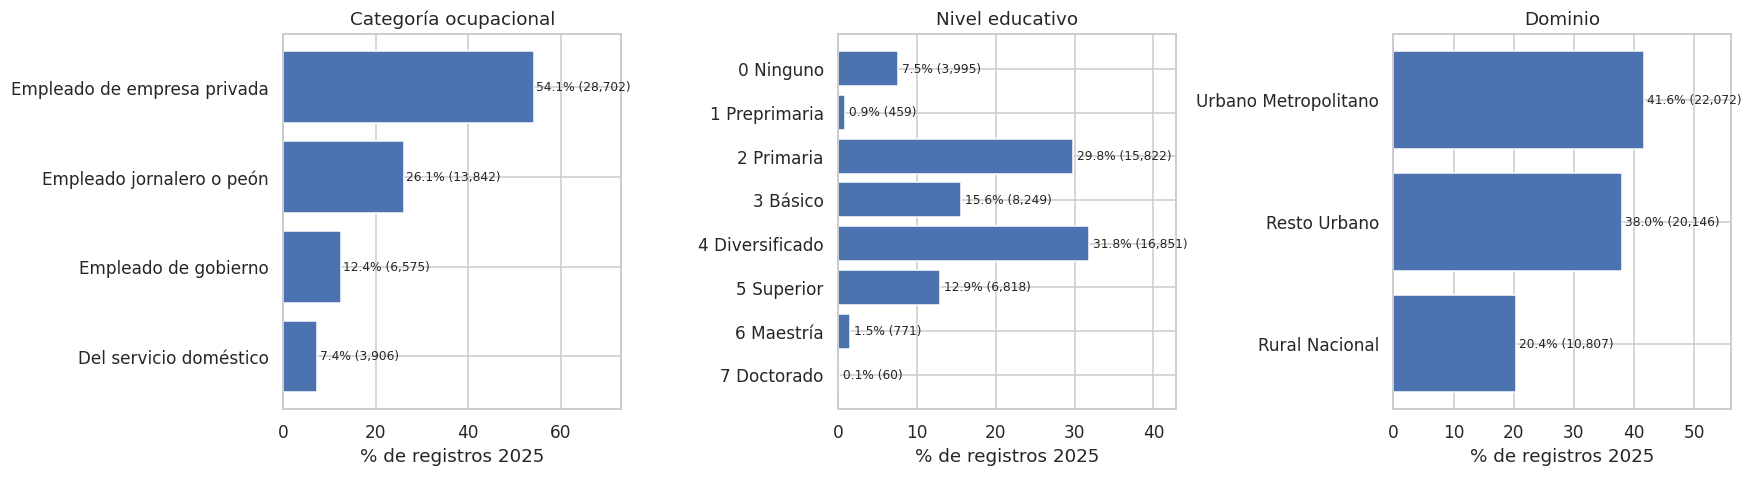

registros     %
categoría Empleado de empresa privada      28702 54.13
          Empleado jornalero o peón        13842 26.10
          Empleado de gobierno              6575 12.40
          Del servicio doméstico            3906  7.37
educación 0 Ninguno                         3995  7.53
          1 Preprimaria                      459  0.87
          2 Primaria                       15822 29.84
          3 Básico                          8249 15.56
          4 Diversificado                  16851 31.78
          5 Superior                        6818 12.86
          6 Maestría                         771  1.45
          7 Doctorado                         60  0.11
dominio   Urbano Metropolitano             22072 41.63
          Resto Urbano                     20146 37.99
          Rural Nacional                   10807 20.38

In [17]:
def distribucion(df, col, orden=None):
    t = df.groupBy(col).count().toPandas().set_index(col)["count"]
    t = t.reindex(orden).dropna() if orden else t.sort_values(ascending=False)
    return pd.DataFrame({"registros": t.astype(int), "%": t / t.sum() * 100})

dist_cat = distribucion(df25, "categoria_ocupacional")
dist_edu = distribucion(df25, "nivel_educativo", ORDEN_EDU)
dist_dom = distribucion(df25, "dominio", ORDEN_DOM)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (titulo, t) in zip(axes, [("Categoría ocupacional", dist_cat), ("Nivel educativo", dist_edu), ("Dominio", dist_dom)]):
    ax.barh(t.index[::-1], t["%"][::-1], color="#4C72B0")
    for i, (v, n) in enumerate(zip(t["%"][::-1], t["registros"][::-1])):
        ax.text(v + 0.5, i, f"{v:.1f}% ({n:,})", va="center", fontsize=8)
    ax.set_title(titulo)
    ax.set_xlabel("% de registros 2025")
    ax.set_xlim(0, t["%"].max() * 1.35)
plt.tight_layout()
guardar_fig("distribucion_categoricas")
plt.show()
display(pd.concat({"categoría": dist_cat, "educación": dist_edu, "dominio": dist_dom}))

**Interpretación**
- **Categoría ocupacional:** predominan los empleados de empresa privada (54.1%), seguidos de jornaleros o peones (26.1%). Gobierno (12.4%) y servicio doméstico (7.4%) son grupos más pequeños.
- **Nivel educativo:** la mayoría tiene diversificado (31.8%) o primaria (29.8%), luego básico (15.6%) y superior (12.9%). Un 7.5% no tiene ningún nivel aprobado (código 0, que es "ninguno" y no un faltante). Preprimaria (459 registros), maestría (771) y doctorado (60) son grupos pequeños, así que sus estadísticas son menos estables. No quedó ningún registro `DESCONOCIDO` en la población analítica.
- **Dominio:** 41.6% urbano metropolitano, 38.0% resto urbano y 20.4% rural nacional. La menor presencia rural refleja que en el área rural predominan el trabajo por cuenta propia y el agrícola no asalariado. Además, al no ponderar, estas proporciones no reproducen la distribución poblacional.

### 2.2 Forma de la distribución del salario (simetría, media vs. mediana)

Los histogramas se construyen con **conteos agregados en Spark** sobre todos los registros. El panel derecho usa el eje X en **escala logarítmica (log10)** solo para visualizar; el modelado usa el salario en quetzales.

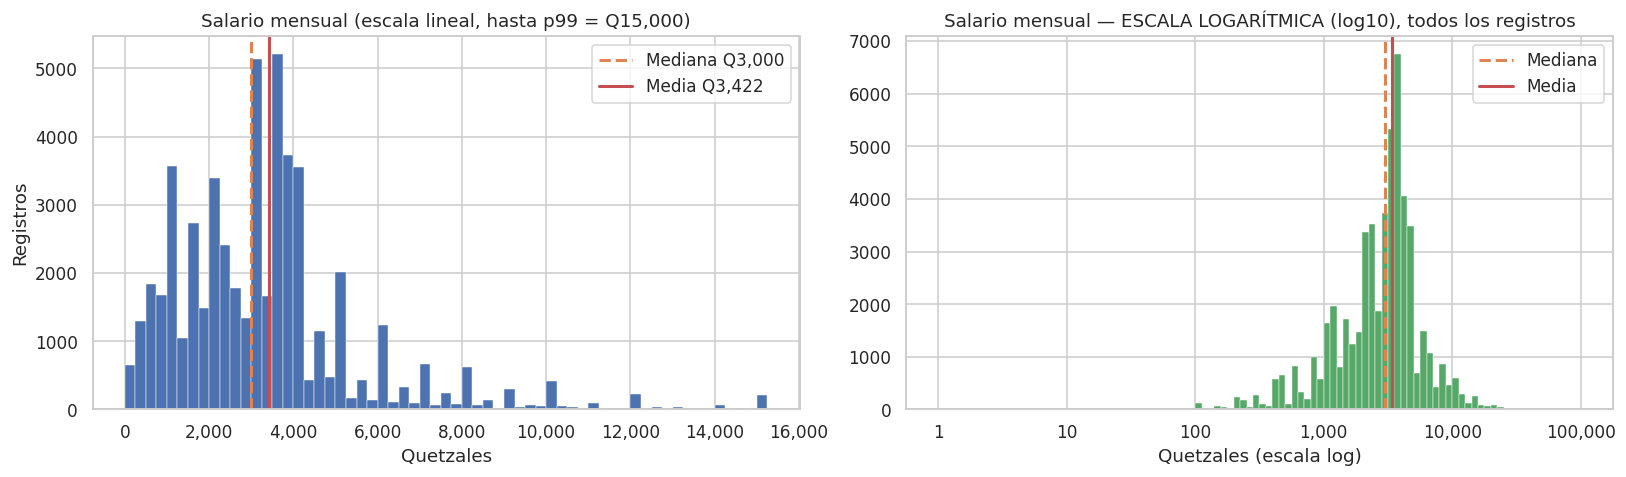

Media Q3,421.68 | Mediana Q3,000.00 | Diferencia Q421.68 (14.1% sobre la mediana) | Asimetría 6.00
Registros por encima del p99 (no mostrados en el panel lineal): 376
Colas:  {'salario < Q100': 22, 'salario < Q500': 1946, 'salario > Q20,000': 145}


In [18]:
media_sal, mediana_sal, p99_sal = df25.agg(
    F.mean("salario_mensual"), F.expr("percentile(salario_mensual, 0.5)"), F.expr("percentile(salario_mensual, 0.99)")
).first()

ANCHO_Q = 250
hist_lin = (df25.filter(F.col("salario_mensual") <= p99_sal)
            .groupBy((F.floor(F.col("salario_mensual") / ANCHO_Q) * ANCHO_Q).alias("bin")).count()
            .toPandas().sort_values("bin"))
ANCHO_LOG = 0.05
hist_log = (df25.groupBy((F.floor(F.log10("salario_mensual") / ANCHO_LOG) * ANCHO_LOG).alias("bin")).count()
            .toPandas().sort_values("bin"))

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5))
ax = axes[0]
ax.bar(hist_lin["bin"], hist_lin["count"], width=ANCHO_Q, align="edge", color="#4C72B0", edgecolor="white", linewidth=0.3)
ax.axvline(mediana_sal, color="#DD8452", ls="--", lw=2, label=f"Mediana Q{mediana_sal:,.0f}")
ax.axvline(media_sal, color="#C44E52", ls="-", lw=2, label=f"Media Q{media_sal:,.0f}")
ax.set_title(f"Salario mensual (escala lineal, hasta p99 = Q{p99_sal:,.0f})")
ax.set_xlabel("Quetzales")
ax.set_ylabel("Registros")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.legend()

ax = axes[1]
ax.bar(10 ** hist_log["bin"], hist_log["count"], width=10 ** (hist_log["bin"] + ANCHO_LOG) - 10 ** hist_log["bin"],
       align="edge", color="#55A868", edgecolor="white", linewidth=0.3)
ax.set_xscale("log")
ax.axvline(mediana_sal, color="#DD8452", ls="--", lw=2, label="Mediana")
ax.axvline(media_sal, color="#C44E52", ls="-", lw=2, label="Media")
ax.set_title("Salario mensual — ESCALA LOGARÍTMICA (log10), todos los registros")
ax.set_xlabel("Quetzales (escala log)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.legend()
plt.tight_layout()
guardar_fig("distribucion_salario")
plt.show()

print(f"Media Q{media_sal:,.2f} | Mediana Q{mediana_sal:,.2f} | Diferencia Q{media_sal - mediana_sal:,.2f} "
      f"({(media_sal / mediana_sal - 1) * 100:.1f}% sobre la mediana) | Asimetría {desc25.loc['salario_mensual', 'asimetria']:.2f}")
print(f"Registros por encima del p99 (no mostrados en el panel lineal): {df25.filter(F.col('salario_mensual') > p99_sal).count():,}")
print("Colas: ", df25.agg(*[F.sum(cond.cast('int')).alias(n) for n, cond in [
    ('salario < Q100', F.col('salario_mensual') < 100), ('salario < Q500', F.col('salario_mensual') < 500),
    ('salario > Q20,000', F.col('salario_mensual') > 20000)]]).first().asDict())

**¿Es simétrica la distribución del salario? ¿Qué diferencia hay entre media y mediana?**
- La distribución es **muy asimétrica a la derecha** (coeficiente de asimetría ≈ 6.0). La mayoría de salarios está entre Q1,800 (p25) y Q4,000 (p75), pero la cola derecha llega a **Q99,000**: el p95 es Q8,000, el p99 es Q15,000 y hay 145 registros por encima de Q20,000.
- La **media (Q3,421.68) supera a la mediana (Q3,000)** por Q421.68 (≈14%). Los salarios altos jalan la media hacia arriba, mientras que la mediana es robusta y describe mejor el salario típico. La desviación estándar (Q2,902) es casi del tamaño de la media, lo que confirma la gran dispersión.
- En **escala logarítmica** (panel derecho), la asimetría se reduce mucho y la masa se concentra alrededor de Q3,000–Q4,000. Queda una cola hacia salarios bajos (Q100–Q1,000). En ambos paneles se ven picos en montos redondos (Q1,000, Q2,000, Q3,000, Q4,000…), típicos de salarios reportados en encuesta.
- También hay salarios muy bajos: 22 registros por debajo de Q100 y 1,946 por debajo de Q500. Pueden corresponder a jornadas parciales o a errores de reporte. Según las reglas del laboratorio, se mantienen, igual que los salarios altos.
- **Implicación para el modelado:** el RMSE es muy sensible a los salarios altos de la cola, así que conviene reportarlo junto con el MAE y analizar los errores por percentil.

### 2.3 Salario mediano por nivel educativo y por categoría ocupacional

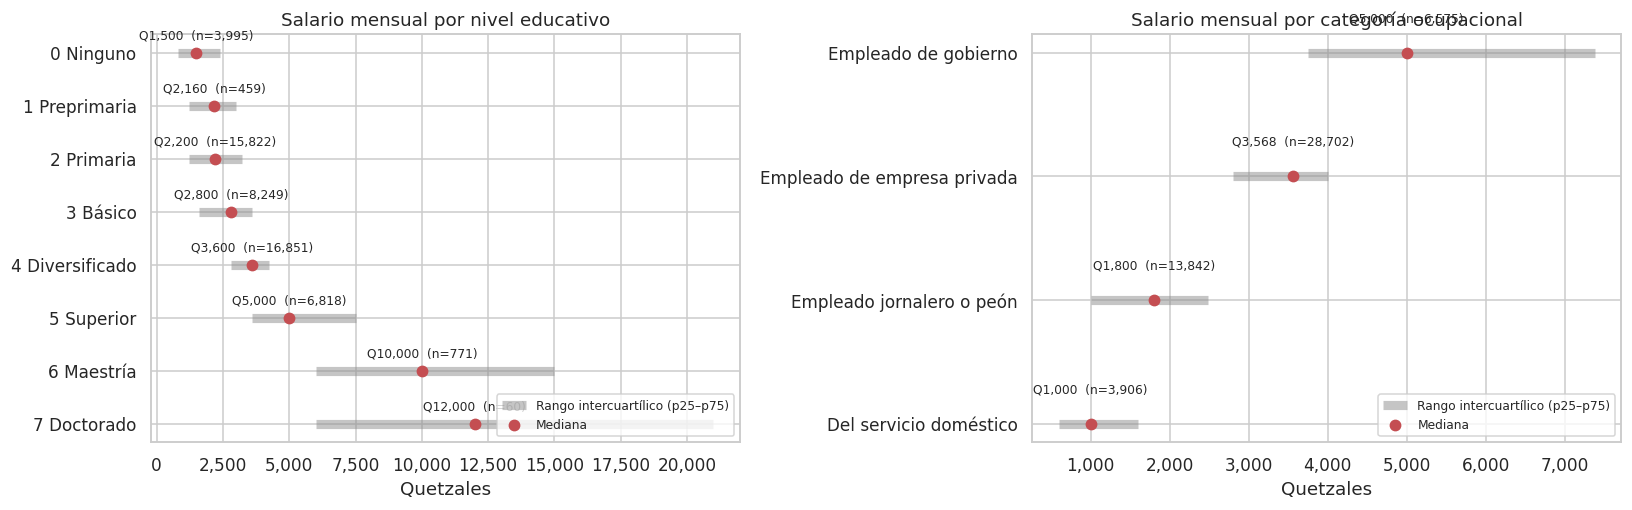

,n,mediana,p25,p75,media
nivel_educativo,,,,,
0 Ninguno,"3,995.00","1,500.00",800.00,"2,400.00","1,767.09"
1 Preprimaria,459.00,"2,160.00","1,200.00","3,000.00","2,241.90"
2 Primaria,"15,822.00","2,200.00","1,200.00","3,200.00","2,307.96"
3 Básico,"8,249.00","2,800.00","1,600.00","3,600.00","2,730.20"
4 Diversificado,"16,851.00","3,600.00","2,800.00","4,250.00","3,796.41"
5 Superior,"6,818.00","5,000.00","3,600.00","7,500.00","5,965.30"
6 Maestría,771.00,"10,000.00","6,000.00","15,000.00","11,409.27"
7 Doctorado,60.00,"12,000.00","6,000.00","21,000.00","14,452.27"


,n,mediana,p25,p75,media
categoria_ocupacional,,,,,
Empleado de gobierno,6575,"5,000.00","3,750.00","7,380.00","5,971.53"
Empleado de empresa privada,28702,"3,567.50","2,800.00","4,000.00","3,875.14"
Empleado jornalero o peón,13842,"1,800.00","1,000.00","2,489.75","1,878.61"
Del servicio doméstico,3906,"1,000.00",600.00,"1,600.00","1,265.74"


In [19]:
def mediana_por(df, col, orden=None):
    t = (df.groupBy(col).agg(F.count(F.lit(1)).alias("n"),
                             F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                             F.expr("percentile(salario_mensual, 0.25)").alias("p25"),
                             F.expr("percentile(salario_mensual, 0.75)").alias("p75"),
                             F.mean("salario_mensual").alias("media"))
         .toPandas().set_index(col))
    return t.reindex(orden).dropna(how="all") if orden else t.sort_values("mediana", ascending=False)

med_edu = mediana_por(df25, "nivel_educativo", ORDEN_EDU)
med_cat = mediana_por(df25, "categoria_ocupacional")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))
for ax, (titulo, t) in zip(axes, [("Nivel educativo", med_edu), ("Categoría ocupacional", med_cat)]):
    y = np.arange(len(t))[::-1]
    ax.hlines(y, t["p25"], t["p75"], color="#8C8C8C", lw=6, alpha=0.5, label="Rango intercuartílico (p25–p75)")
    ax.scatter(t["mediana"], y, color="#C44E52", zorder=3, s=45, label="Mediana")
    for yi, (m, n) in zip(y, zip(t["mediana"], t["n"])):
        ax.text(m, yi + 0.25, f"Q{m:,.0f}  (n={n:,.0f})", ha="center", fontsize=8)
    ax.set_yticks(y, t.index)
    ax.set_title(f"Salario mensual por {titulo.lower()}")
    ax.set_xlabel("Quetzales")
    ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.legend(loc="lower right", fontsize=8)
plt.tight_layout()
guardar_fig("salario_educacion_categoria")
plt.show()
display(med_edu, med_cat)

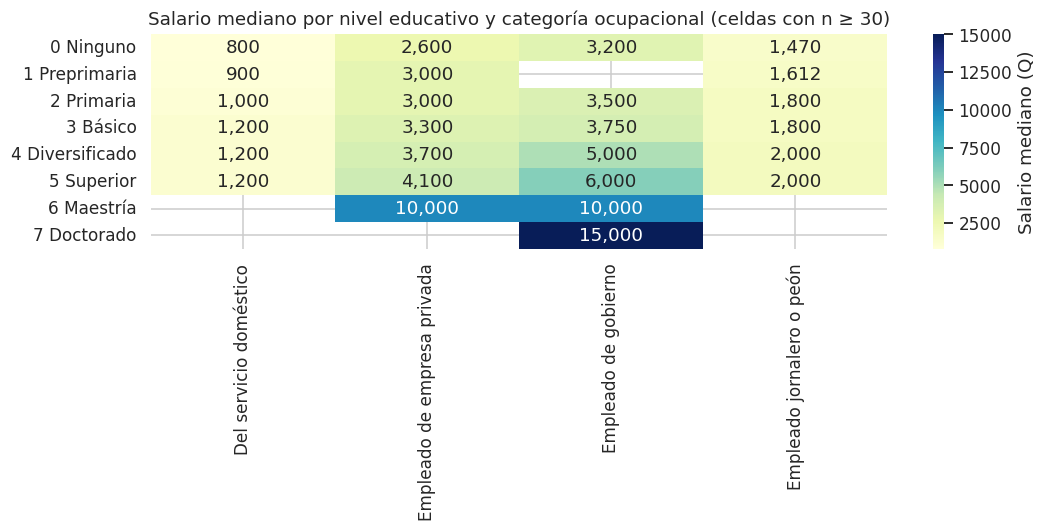

In [20]:
# Mediana cruzada educación x categoría (celdas con < 30 registros se ocultan)
cruce = (df25.groupBy("nivel_educativo", "categoria_ocupacional")
         .agg(F.count(F.lit(1)).alias("n"), F.expr("percentile(salario_mensual, 0.5)").alias("mediana")).toPandas())
piv = cruce.pivot(index="nivel_educativo", columns="categoria_ocupacional", values="mediana").reindex(ORDEN_EDU).dropna(how="all")
piv_n = cruce.pivot(index="nivel_educativo", columns="categoria_ocupacional", values="n").reindex(piv.index)
fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(piv.where(piv_n >= 30), annot=True, fmt=",.0f", cmap="YlGnBu", cbar_kws={"label": "Salario mediano (Q)"}, ax=ax)
ax.set_title("Salario mediano por nivel educativo y categoría ocupacional (celdas con n ≥ 30)")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

**Interpretación**
- **Educación:** el salario mediano crece de forma monótona con el nivel educativo: Q1,500 (ninguno) → Q2,200 (primaria) → Q2,800 (básico) → Q3,600 (diversificado) → Q5,000 (superior) → Q10,000 (maestría) → Q12,000 (doctorado). El salto más grande está en superior y posgrado, donde también se amplía mucho el rango intercuartílico: hay más heterogeneidad salarial entre profesionales.
- **Categoría ocupacional:** los empleados de gobierno tienen la mediana más alta (Q5,000), seguidos de empresa privada (Q3,567.50). Jornaleros o peones (Q1,800) y servicio doméstico (Q1,000) están muy por debajo.
- El mapa de calor muestra que el gradiente educativo se mantiene **dentro** de empresa privada (Q2,600 sin educación → Q4,100 superior → Q10,000 maestría) y gobierno (Q3,200 → Q6,000 → Q15,000 doctorado). En cambio, en servicio doméstico (Q800–Q1,200) y jornaleros (Q1,470–Q2,000) casi no cambia. Es decir, el efecto de la educación depende de la categoría (hay una **interacción**). Esto importa para el modelado: una regresión lineal sin interacciones no puede capturarlo, mientras que un Random Forest sí. Son asociaciones descriptivas, no efectos causales.

### 2.4 Tamaño de la muestra analítica y salario mediano por trimestre

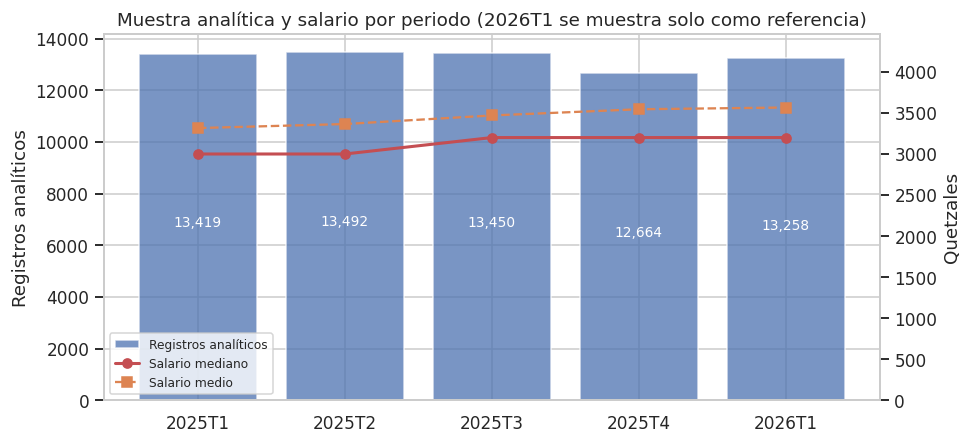

,n,mediana,media,antes,% del archivo
periodo_archivo,,,,,
2025T1,13419,"3,000.00","3,315.63",51588,26.01
2025T2,13492,"3,000.00","3,364.57",51167,26.37
2025T3,13450,"3,200.00","3,469.07",51583,26.07
2025T4,12664,"3,200.00","3,544.57",49338,25.67
2026T1,13258,"3,200.00","3,565.80",49843,26.60


In [21]:
por_trim = (analitica.groupBy("periodo_archivo")
            .agg(F.count(F.lit(1)).alias("n"),
                 F.expr("percentile(salario_mensual, 0.5)").alias("mediana"),
                 F.mean("salario_mensual").alias("media"))
            .toPandas().set_index("periodo_archivo").sort_index())
por_trim = por_trim.join(conteo[["antes"]])
por_trim["% del archivo"] = por_trim["n"] / por_trim["antes"] * 100

fig, ax1 = plt.subplots(figsize=(9, 4.2))
ax1.bar(por_trim.index, por_trim["n"], color="#4C72B0", alpha=0.75, label="Registros analíticos")
for i, n in enumerate(por_trim["n"]):
    ax1.text(i, n / 2, f"{n:,}", ha="center", color="white", fontsize=9)
ax1.set_ylabel("Registros analíticos")
ax2 = ax1.twinx()
ax2.plot(por_trim.index, por_trim["mediana"], color="#C44E52", marker="o", lw=2, label="Salario mediano")
ax2.plot(por_trim.index, por_trim["media"], color="#DD8452", marker="s", lw=1.5, ls="--", label="Salario medio")
ax2.set_ylabel("Quetzales")
ax2.set_ylim(0, por_trim["media"].max() * 1.25)
ax2.grid(False)
h1, l1 = ax1.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower left", fontsize=8)
ax1.set_title("Muestra analítica y salario por periodo (2026T1 se muestra solo como referencia)")
plt.tight_layout()
guardar_fig("muestra_salario_periodo")
plt.show()
por_trim

**Interpretación**
- El **tamaño de la muestra analítica** es estable: entre 12,664 (2025T4) y 13,492 (2025T2) registros, siempre alrededor del 26% del archivo. 2025T4 es el trimestre con menos registros.
- El **salario mediano** pasa de Q3,000 (2025T1–T2) a Q3,200 (2025T3, 2025T4 y 2026T1). El salario medio sube de forma gradual, de Q3,315.63 a Q3,544.57 en 2025T4 y Q3,565.80 en 2026T1 (≈ +7.5%). Son montos nominales, sin ajuste por inflación.
- **Implicación:** el conjunto de prueba (2026T1) tiene salarios algo más altos que el promedio de 2025. Un modelo entrenado con 2025 podría **subestimar ligeramente** los salarios de 2026 (un pequeño cambio de distribución en el tiempo).

## 3. Relaciones entre variables numéricas

Correlación de **Pearson** con `VectorAssembler` + `Correlation.corr()` sobre todos los registros elegibles de 2025. Como el salario es muy asimétrico, se agrega **Spearman** (correlación de rangos) como complemento.

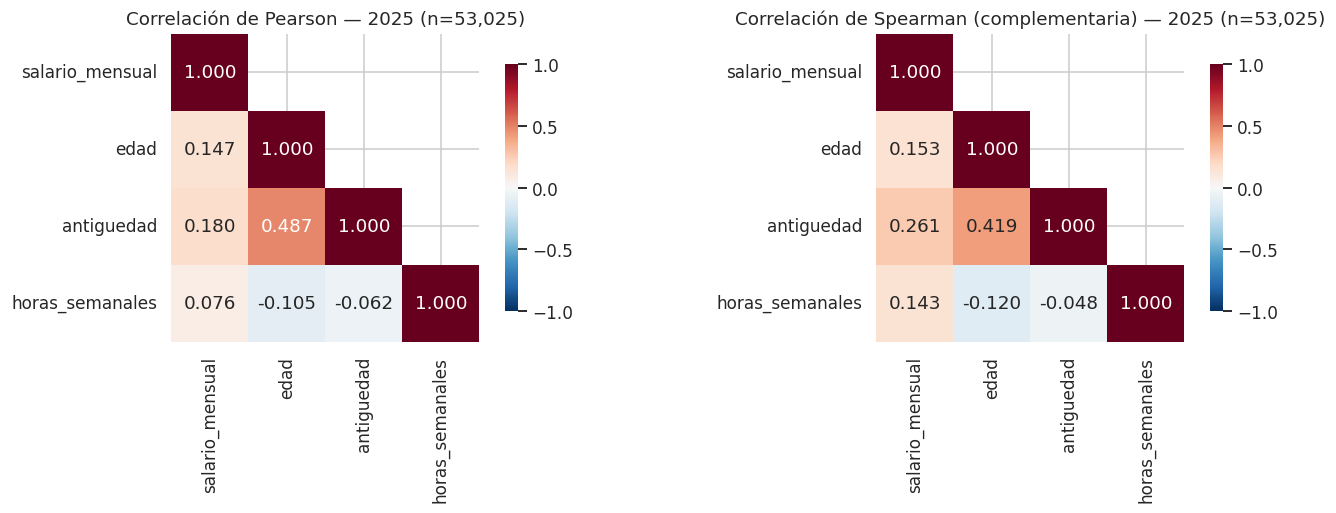

,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


In [22]:
vec_corr = VectorAssembler(inputCols=VARS_NUM, outputCol="vars").transform(df25).select("vars")
corr_pearson = pd.DataFrame(Correlation.corr(vec_corr, "vars", "pearson").head()[0].toArray(), index=VARS_NUM, columns=VARS_NUM)
corr_spearman = pd.DataFrame(Correlation.corr(vec_corr, "vars", "spearman").head()[0].toArray(), index=VARS_NUM, columns=VARS_NUM)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
for ax, (titulo, m) in zip(axes, [("Pearson", corr_pearson), ("Spearman (complementaria)", corr_spearman)]):
    sns.heatmap(m, annot=True, fmt=".3f", cmap="RdBu_r", vmin=-1, vmax=1, square=True, ax=ax,
                mask=np.triu(np.ones_like(m, dtype=bool), k=1), cbar_kws={"shrink": 0.8})
    ax.set_title(f"Correlación de {titulo} — 2025 (n={df25.count():,})")
plt.tight_layout()
guardar_fig("correlaciones")
plt.show()
display(corr_pearson.style.format("{:.3f}").set_caption("Matriz de correlación de Pearson"))

**¿Qué variables tienen mayor asociación lineal con el salario?**
Todas las correlaciones de Pearson con el salario son **positivas pero débiles**: antigüedad (0.180), edad (0.147) y horas habituales (0.076). Ninguna variable numérica por sí sola explica una parte importante de la variación salarial (el mayor r² individual es ≈ 0.03). Con Spearman las asociaciones son algo mayores, en especial para horas (0.143 vs. 0.076) y antigüedad (0.261). Eso indica relaciones monótonas pero no lineales, y que los salarios extremos debilitan la correlación de Pearson. Junto con la sección 2.3, esto sugiere que las variables categóricas (educación y categoría ocupacional) serán más informativas que las numéricas.

**¿Existe relación entre edad y antigüedad?**
Sí. Es la asociación más fuerte de la matriz: **r = 0.487** (Spearman 0.419), positiva y moderada. Las personas mayores tienden a acumular más años en su empleo actual, y la edad limita la antigüedad posible. No es tan alta como para causar multicolinealidad grave en la regresión, pero ambas variables comparten información. Horas y edad tienen una relación débil y negativa (−0.105).

## 4. Segmentación de perfiles con KMeans

**Diseño**
- Las variables se estandarizan con `StandardScaler` (media 0, desviación 1) porque tienen escalas muy distintas (años vs. horas vs. quetzales).
- Se prueban **K = 2, 3, 4 y 5**. Para cada K se entrena KMeans con 3 semillas fijas y se conserva la solución de menor inercia, para no depender de una sola inicialización. Para cada K se registran el **coeficiente de silueta** (distancia euclídea al cuadrado), la **inercia (WSSSE)** y el tamaño del cluster más pequeño.
- Se comparan tres conjuntos de variables para decidir si vale la pena incluir el salario:
  - **A:** edad, antigüedad y horas (perfil laboral)
  - **B:** A + salario en quetzales
  - **C:** A + log10(salario)

In [23]:
df25_km = df25.withColumn("log_salario", F.log10("salario_mensual")).cache()

CONJUNTOS = {
    "A: edad, antigüedad, horas": ["edad", "antiguedad", "horas_semanales"],
    "B: A + salario (Q)": ["edad", "antiguedad", "horas_semanales", "salario_mensual"],
    "C: A + log10(salario)": ["edad", "antiguedad", "horas_semanales", "log_salario"],
}
KS = [2, 3, 4, 5]
evaluador_sil = ClusteringEvaluator(featuresCol="features", metricName="silhouette", distanceMeasure="squaredEuclidean")

def preparar_km(df, cols):
    prep = Pipeline(stages=[VectorAssembler(inputCols=cols, outputCol="x_raw"),
                            StandardScaler(inputCol="x_raw", outputCol="features", withMean=True, withStd=True)]).fit(df)
    return prep, prep.transform(df).cache()

resultados_km, modelos_km, datos_km = [], {}, {}
for nombre, cols in CONJUNTOS.items():
    prep, X = preparar_km(df25_km, cols)
    datos_km[nombre] = (prep, X)
    for k in KS:
        candidatos = [KMeans(k=k, seed=SEED + s, featuresCol="features", predictionCol="cluster", maxIter=100).fit(X) for s in range(3)]
        km = min(candidatos, key=lambda m: m.summary.trainingCost)
        pred = km.transform(X)
        tam = pred.groupBy("cluster").count().toPandas()["count"]
        modelos_km[(nombre, k)] = km
        resultados_km.append({"conjunto": nombre, "K": k, "silueta": evaluador_sil.evaluate(pred.withColumnRenamed("cluster", "prediction")),
                              "WSSSE": km.summary.trainingCost, "cluster_min_%": tam.min() / tam.sum() * 100})
resultados_km = pd.DataFrame(resultados_km)
resultados_km.pivot(index="K", columns="conjunto", values=["silueta", "WSSSE", "cluster_min_%"])

silueta                                                               WSSSE                                                       cluster_min_%                     \
conjunto A: edad, antigüedad, horas B: A + salario (Q) C: A + log10(salario) A: edad, antigüedad, horas B: A + salario (Q) C: A + log10(salario) A: edad, antigüedad, horas B: A + salario (Q)   
K                                                                                                                                                                                                
2                              0.55               0.51                  0.47                 106,717.39         157,345.56            159,174.06                      27.51              27.03   
3                              0.47               0.36                  0.48                  83,608.00         133,746.95            125,145.16                      19.08              20.47   
4                              0.47               0.37                  0.37                  64,437.03         113,556.65            107,227.29                      12.91              14.26   
5                              0.48               0.41                  0.39                  54,990.35          94,475.67             91,787.88                      11.65               3.98   

                                
conjunto C: A + log10(salario)  
K                               
2                        28.20  
3                        17.62  
4                        11.43  
5                        10.98

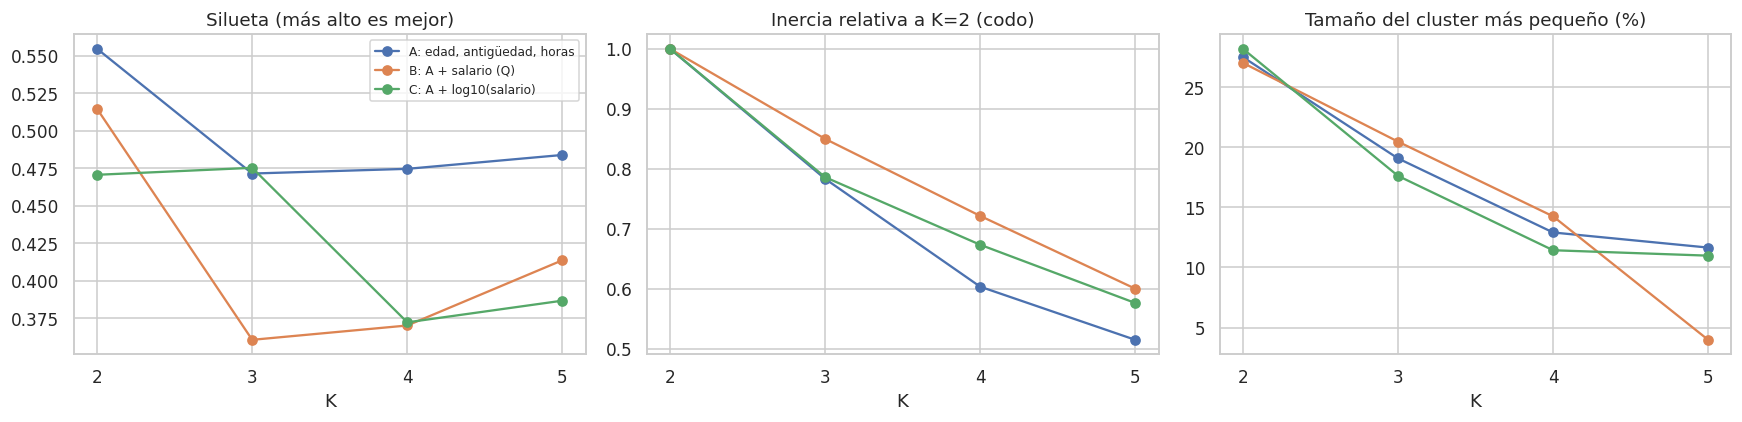

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for nombre, g in resultados_km.groupby("conjunto", sort=False):
    axes[0].plot(g["K"], g["silueta"], marker="o", label=nombre)
    axes[1].plot(g["K"], g["WSSSE"] / g["WSSSE"].iloc[0], marker="o", label=nombre)
    axes[2].plot(g["K"], g["cluster_min_%"], marker="o", label=nombre)
axes[0].set_title("Silueta (más alto es mejor)")
axes[1].set_title("Inercia relativa a K=2 (codo)")
axes[2].set_title("Tamaño del cluster más pequeño (%)")
for ax in axes:
    ax.set_xticks(KS)
    ax.set_xlabel("K")
axes[0].legend(fontsize=8)
plt.tight_layout()
guardar_fig("seleccion_k")
plt.show()

In [25]:
# ¿Qué hace el salario en bruto (conjunto B)? Perfil de clusters con K=5 (donde aparece el cluster más pequeño de B) para ver si aísla salarios extremos
_, Xb = datos_km["B: A + salario (Q)"]
(modelos_km[("B: A + salario (Q)", 5)].transform(Xb).groupBy("cluster")
 .agg(F.count(F.lit(1)).alias("n"), F.round(F.mean("edad"), 1).alias("edad"), F.round(F.mean("antiguedad"), 1).alias("antig"),
      F.round(F.mean("horas_semanales"), 1).alias("horas"), F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano"),
      F.min("salario_mensual").alias("salario_min"), F.max("salario_mensual").alias("salario_max"))
 .orderBy("salario_mediano").toPandas())

,cluster,n,edad,antig,horas,salario_mediano,salario_min,salario_max
0,1,11474,49.00,3.80,39.10,"2,800.00",1.00,"8,250.00"
1,2,24238,25.80,2.40,41.00,"3,000.00",30.00,"9,112.00"
2,0,8885,30.60,3.50,74.70,"3,000.00",100.00,"11,000.00"
3,3,6320,49.90,22.40,41.40,"3,600.00",70.00,"13,000.00"
4,4,2108,43.10,9.50,41.90,"11,000.00","7,500.00","99,000.00"


**¿Vale la pena incluir el salario en la segmentación?**
Decidimos **no incluirlo** (usamos el conjunto A) por tres razones:
1. **El salario en quetzales (B) se dedica a aislar la cola.** Con K=5, uno de los clusters agrupa solo al 4.0% de los registros (2,108), con salarios de Q7,500 a Q99,000 y mediana de Q11,000. Los otros cuatro reproducen los perfiles de edad, antigüedad y jornada del conjunto A y casi no difieren en salario (medianas de Q2,800 a Q3,600). La silueta de B es menor que la de A para todos los K.
2. **Con log10(salario) (C)** la silueta mejora solo en K=3 (0.48 vs. 0.47) y es menor en K=2, 4 y 5. No hay una ganancia clara que justifique mezclar el resultado salarial con el perfil laboral.
3. **Interpretación:** la pregunta del laboratorio busca perfiles según edad, antigüedad y jornada. Si el salario forma los clusters, los perfiles quedan definidos en parte por el resultado que después queremos describir. Es mejor segmentar por condiciones laborales y usar el salario como **variable descriptiva** de cada segmento.

**Elección de K (criterio del grupo)**
Elegimos el K con **mayor silueta entre K ≥ 3**, siempre que ningún cluster tenga menos del 10% de los registros y que los perfiles se puedan interpretar. K=2 tiene la silueta más alta (0.55), pero dos grupos son demasiado gruesos para describir perfiles. Entre K=3, 4 y 5 las siluetas son casi iguales (0.47, 0.47 y 0.48). La inercia no muestra un codo marcado: sigue bajando de forma gradual (−22%, −23% y −15%).
**K = 5** tiene la mejor silueta de ese rango, su cluster más pequeño representa el 11.7% y, sobre todo, separa un perfil que K=4 no distingue: el de **jornada parcial**.

In [26]:
CONJUNTO_ELEGIDO = "A: edad, antigüedad, horas"
K_ELEGIDO = 5

prep_km, X_km = datos_km[CONJUNTO_ELEGIDO]
km_final = modelos_km[(CONJUNTO_ELEGIDO, K_ELEGIDO)]
seg = km_final.transform(X_km)

# Nombres de segmento asignados con reglas sobre los centroides en unidades originales
# (así no dependen del id interno que KMeans asigna a cada cluster)
escalador = prep_km.stages[-1]
cent = pd.DataFrame(km_final.clusterCenters(), columns=CONJUNTOS[CONJUNTO_ELEGIDO])
cent_orig = cent * escalador.std.toArray() + escalador.mean.toArray()

def describir(c):
    if c["horas_semanales"] < 30:
        return "Jornada parcial"
    if c["horas_semanales"] > 60:
        return "Jornada extensa"
    if c["antiguedad"] > 12:
        return "Veteranos de larga antigüedad"
    if c["edad"] >= 40:
        return "Adultos con antigüedad corta"
    return "Jóvenes en jornada completa"

orden = cent_orig.sort_values(["edad", "antiguedad"]).index
remap = {int(idx): f"C{i + 1} {describir(cent_orig.loc[idx])}" for i, idx in enumerate(orden)}
SEGMENTOS = [remap[int(i)] for i in orden]
seg = seg.withColumn("segmento", mapa_spark({str(k): v for k, v in remap.items()})[F.col("cluster").cast("string")]).cache()

cent_z = pd.concat({"z (estandarizado)": cent, "unidades originales": cent_orig}, axis=1).rename(index=remap).loc[SEGMENTOS]
perfil = (seg.groupBy("segmento").agg(
    F.count(F.lit(1)).alias("n"),
    F.mean("edad").alias("edad_media"), F.expr("percentile(edad, 0.5)").alias("edad_mediana"),
    F.mean("antiguedad").alias("antig_media"), F.expr("percentile(antiguedad, 0.5)").alias("antig_mediana"),
    F.mean("horas_semanales").alias("horas_media"), F.expr("percentile(horas_semanales, 0.5)").alias("horas_mediana"),
    F.expr("percentile(salario_mensual, 0.5)").alias("salario_mediano*"),
    F.mean("salario_mensual").alias("salario_medio*"),
).toPandas().set_index("segmento").sort_index())
perfil.insert(1, "%", perfil["n"] / perfil["n"].sum() * 100)
print("Centroides:")
display(cent_z.style.format("{:.2f}").background_gradient(cmap="RdBu_r", vmin=-2, vmax=2, axis=None, subset=["z (estandarizado)"]))
print("Perfil en unidades originales (* el salario es descriptivo: no se usó para formar los clusters si el conjunto es A):")
perfil

Centroides:


Perfil en unidades originales (* el salario es descriptivo: no se usó para formar los clusters si el conjunto es A):


,n,%,edad_media,edad_mediana,antig_media,antig_mediana,horas_media,horas_mediana,salario_mediano*,salario_medio*
segmento,,,,,,,,,,
C1 Jóvenes en jornada completa,22715,42.84,26.33,26.00,2.55,1.50,47.55,48.00,"3,200.00","3,370.94"
C2 Jornada parcial,6502,12.26,29.75,30.00,2.88,1.17,19.39,21.00,"1,200.00","1,943.87"
C3 Jornada extensa,6179,11.65,31.12,30.00,3.69,2.00,80.77,76.00,"3,000.00","3,266.90"
C4 Adultos con antigüedad corta,11005,20.75,49.96,48.00,4.18,3.00,43.36,44.00,"3,200.00","3,707.10"
C5 Veteranos de larga antigüedad,6624,12.49,50.17,49.00,22.52,20.00,41.22,40.00,"3,800.00","4,716.50"


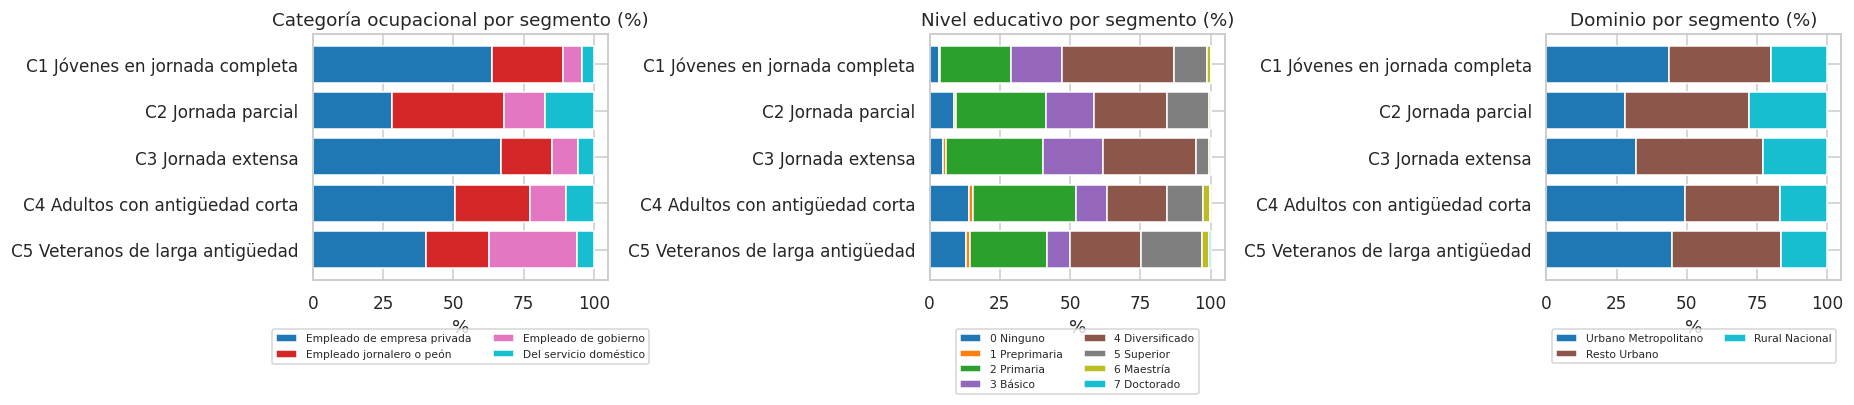

segmento                               C1 Jóvenes en jornada completa  C2 Jornada parcial  C3 Jornada extensa  C4 Adultos con antigüedad corta  C5 Veteranos de larga antigüedad
categoría Empleado de empresa privada                           63.80               28.10               67.00                            50.70                             40.40
          Empleado jornalero o peón                             25.30               40.00               17.90                            26.40                             22.20
          Empleado de gobierno                                   6.70               14.70                9.50                            12.90                             31.50
          Del servicio doméstico                                 4.10               17.30                5.60                            10.00                              5.90
educación 0 Ninguno                                              3.30                8.50                4.90                            14.00                             13.10
          1 Preprimaria                                          0.60                1.00                0.90                             1.30                              1.20
          2 Primaria                                            25.10               32.00               34.70                            36.90                             27.60
          3 Básico                                              18.00               17.00               21.20                            10.90                              8.20
          4 Diversificado                                       39.90               26.10               33.20                            21.60                             25.30
          5 Superior                                            12.10               14.80                4.70                            12.60                             21.60
          6 Maestría                                             1.10                0.70                0.40                             2.60                              2.50
          7 Doctorado                                            0.00                0.00                0.00                             0.20                              0.50
dominio   Urbano Metropolitano                                  43.60               28.00               31.90                            49.20                             44.60
          Resto Urbano                                          36.10               44.00               45.10                            33.80                             38.90
          Rural Nacional                                        20.20               28.00               23.10                            17.00                             16.50

In [27]:
def composicion(col, orden=None):
    t = seg.groupBy("segmento", col).count().toPandas().pivot(index="segmento", columns=col, values="count").fillna(0)
    t = t.div(t.sum(axis=1), axis=0) * 100
    return t[[c for c in (orden or t.columns) if c in t.columns]]

comp_cat = composicion("categoria_ocupacional", list(dist_cat.index))
comp_edu = composicion("nivel_educativo", ORDEN_EDU)
comp_dom = composicion("dominio", ORDEN_DOM)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
for ax, (titulo, t) in zip(axes, [("Categoría ocupacional", comp_cat), ("Nivel educativo", comp_edu), ("Dominio", comp_dom)]):
    t.plot(kind="barh", stacked=True, ax=ax, colormap="tab10", width=0.8, legend=False)
    ax.set_title(f"{titulo} por segmento (%)")
    ax.set_xlabel("%")
    ax.set_ylabel("")
    ax.invert_yaxis()
    ax.legend(fontsize=7, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=2)
plt.tight_layout()
plt.show()
display(pd.concat({"categoría": comp_cat, "educación": comp_edu, "dominio": comp_dom}, axis=1).round(1).T)

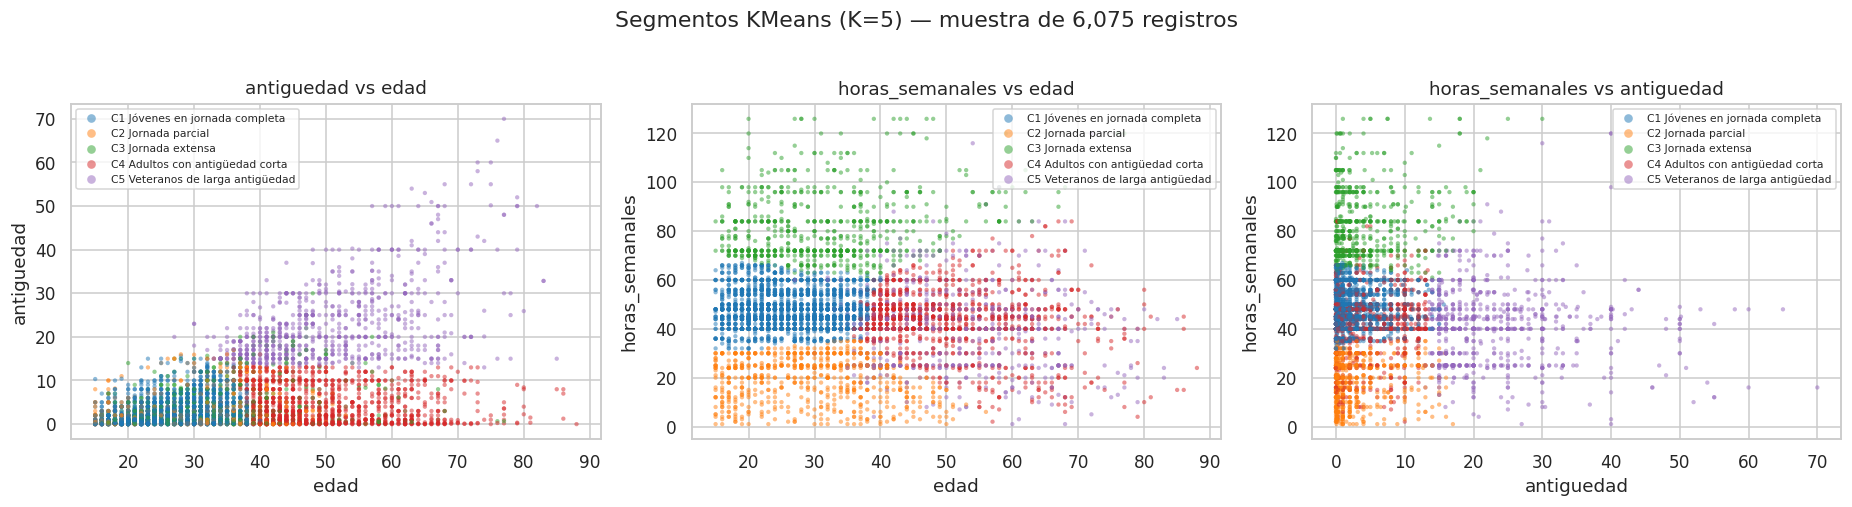

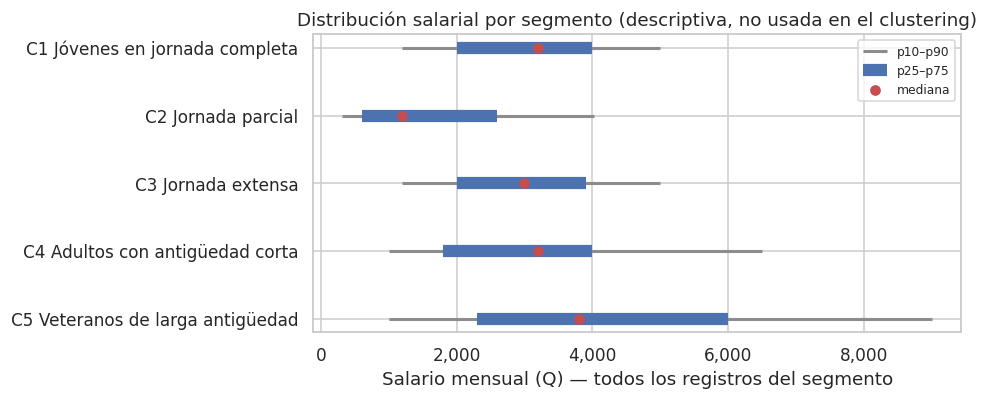

In [28]:
# Visualización con una muestra de hasta 6,000 registros (solo para dibujar)
muestra_seg = seg.select("segmento", "edad", "antiguedad", "horas_semanales").sample(fraction=min(1.0, 6000 / seg.count()), seed=SEED).toPandas()
paleta = dict(zip(SEGMENTOS, sns.color_palette("tab10")))
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (x, y) in zip(axes, [("edad", "antiguedad"), ("edad", "horas_semanales"), ("antiguedad", "horas_semanales")]):
    sns.scatterplot(data=muestra_seg, x=x, y=y, hue="segmento", hue_order=SEGMENTOS, palette=paleta, s=8, alpha=0.5, ax=ax, linewidth=0)
    ax.set_title(f"{y} vs {x}")
    ax.legend(markerscale=2, fontsize=7)
plt.suptitle(f"Segmentos KMeans (K={K_ELEGIDO}) — muestra de {len(muestra_seg):,} registros", y=1.02)
plt.tight_layout()
guardar_fig("segmentos_dispersion")
plt.show()

fig, ax = plt.subplots(figsize=(9, 3.8))
sal_seg = (seg.groupBy("segmento").agg(*[F.expr(f"percentile(salario_mensual, {q})").alias(f"p{int(q * 100)}") for q in (0.1, 0.25, 0.5, 0.75, 0.9)])
           .toPandas().set_index("segmento").sort_index())
y = np.arange(len(sal_seg))[::-1]
ax.hlines(y, sal_seg["p10"], sal_seg["p90"], color="#8C8C8C", lw=2, label="p10–p90")
ax.hlines(y, sal_seg["p25"], sal_seg["p75"], color="#4C72B0", lw=8, label="p25–p75")
ax.scatter(sal_seg["p50"], y, color="#C44E52", zorder=3, label="mediana")
ax.set_yticks(y, sal_seg.index)
ax.set_xlabel("Salario mensual (Q) — todos los registros del segmento")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
ax.set_title("Distribución salarial por segmento (descriptiva, no usada en el clustering)")
ax.legend(fontsize=8)
plt.tight_layout()
guardar_fig("salario_por_segmento")
plt.show()

**Descripción de los segmentos (K = 5, variables: edad, antigüedad y horas estandarizadas)**

| Segmento | Tamaño | Perfil | Rasgos asociados (descriptivos) |
|---|---|---|---|
| **C1 Jóvenes en jornada completa** | ~43% | ~26 años, ~2.6 años de antigüedad, ~47 h/semana | Es el grupo más grande. Predomina el empleo en empresa privada. Salario mediano ≈ Q3,200. |
| **C2 Jornada parcial** | ~12% | ~30 años, poca antigüedad, **~19 h/semana** | Salario mediano más bajo (≈ Q1,200): el salario mensual refleja menos horas. Mayor proporción de jornaleros (~40%) y de servicio doméstico (~17%). |
| **C3 Jornada extensa** | ~12% | ~31 años, poca antigüedad, **~81 h/semana** | Muy alta proporción en empresa privada y el menor porcentaje con educación superior (~5%). Trabajar muchas horas **no** se traduce en mayor salario (mediana ≈ Q3,000). |
| **C4 Adultos con antigüedad corta** | ~21% | ~50 años, ~4 años de antigüedad, ~43 h/semana | Adultos que cambiaron de empleo o se incorporaron hace poco. Su salario es similar al de los jóvenes (≈ Q3,200). |
| **C5 Veteranos de larga antigüedad** | ~12% | ~50 años, **~22 años de antigüedad**, ~41 h/semana | Mayor salario mediano (≈ Q3,800), la mayor proporción de empleados de gobierno (~31%) y de educación superior (~25%). |

**Lectura general**
- La segmentación se organiza en dos ejes: **edad y antigüedad** (C1–C3 jóvenes vs. C4–C5 mayores) y **jornada** (parcial, completa o extensa).
- La antigüedad larga (C5) es el rasgo asociado a salarios más altos y a empleo público.
- La jornada parcial (C2) concentra los salarios mensuales bajos.
- Con la silueta ≈ 0.48, la estructura es moderada: los segmentos se traslapan y deben verse como perfiles típicos, no como grupos cerrados.
- El salario y la composición por categoría, educación y dominio son **descriptivos**: no se usaron para formar los clusters. La etiqueta de segmento **no** se usará como predictor en los modelos supervisados.

## 5. Preparación de conjuntos para modelado supervisado

División **temporal** (no aleatoria) sobre la población analítica ya preparada:

| Conjunto | Periodos | Uso |
|---|---|---|
| Entrenamiento (selección) | 2025T1 + 2025T2 + 2025T3 | Ajuste de pipelines e hiperparámetros |
| Validación | 2025T4 | Selección por menor RMSE |
| Prueba final | 2026T1 | Evaluación final (no se usa en el ajuste) |

Predictores: `edad`, `antiguedad`, `horas_semanales`, `nivel_educativo`, `categoria_ocupacional`, `dominio`. Objetivo: `salario_mensual` en quetzales (sin recorte ni transformación). Semilla: 42.


In [29]:
PREDICTORES_NUM = ["edad", "antiguedad", "horas_semanales"]
PREDICTORES_CAT = ["nivel_educativo", "categoria_ocupacional", "dominio"]
LABEL = "salario_mensual"
COLS_MODELO = PREDICTORES_NUM + PREDICTORES_CAT + [LABEL]
COLS_AUDITORIA = ["periodo_archivo", "archivo_origen", "NUM_HOGAR", "NUM_PERSONA", "nivel_educativo", "dominio"]

PERIODOS_TRAIN = ["2025T1", "2025T2", "2025T3"]
PERIODO_VAL = "2025T4"

train = df25.filter(F.col("periodo_archivo").isin(PERIODOS_TRAIN)).select(*(COLS_AUDITORIA + COLS_MODELO)).cache()
val = df25.filter(F.col("periodo_archivo") == PERIODO_VAL).select(*(COLS_AUDITORIA + COLS_MODELO)).cache()
test = df26.select(*(COLS_AUDITORIA + COLS_MODELO)).cache()

n_train, n_val, n_test = train.count(), val.count(), test.count()
splits_tbl = pd.DataFrame([
    {"conjunto": "entrenamiento (2025T1–T3)", "filas": n_train, "incluye_2026": int(train.filter(F.col("periodo_archivo").startswith("2026")).count())},
    {"conjunto": "validación (2025T4)", "filas": n_val, "incluye_2026": int(val.filter(F.col("periodo_archivo").startswith("2026")).count())},
    {"conjunto": "prueba (2026T1)", "filas": n_test, "incluye_2026": int(test.filter(F.col("periodo_archivo").startswith("2026")).count())},
])
assert splits_tbl.loc[0, "incluye_2026"] == 0 and splits_tbl.loc[1, "incluye_2026"] == 0
assert n_train + n_val == df25.count()
display(splits_tbl)
print(f"Suma train+val = {n_train + n_val:,} (debe igualar df25 = {df25.count():,})")

,conjunto,filas,incluye_2026
0,entrenamiento (2025T1–T3),40361,0
1,validación (2025T4),12664,0
2,prueba (2026T1),13258,13258


Suma train+val = 53,025 (debe igualar df25 = 53,025)


**Interpretación.** División temporal sin `randomSplit`: entrenamiento **40,361** filas (2025T1–T3), validación **12,664** (2025T4) y prueba **13,258** (2026T1). Entrenamiento y validación no incluyen 2026. train+val = 53,025 = población analítica de 2025.


## 6. Modelo de referencia (baseline)

Predictor constante igual a la **media de `salario_mensual` calculada solo en entrenamiento (2025T1–T3)**. Se aplica a validación sin recalcularla. No usa predictores; sirve como piso de comparación para MAE, RMSE y R².


In [30]:
def metricas_regresion(pred_df, etiqueta="salario_mensual", prediccion="prediction"):
    ev = {
        m: RegressionEvaluator(labelCol=etiqueta, predictionCol=prediccion, metricName=m).evaluate(pred_df)
        for m in ("mae", "rmse", "r2")
    }
    return ev

media_train = train.agg(F.mean(LABEL)).first()[0]
baseline_val = val.withColumn("prediction", F.lit(float(media_train)))
met_baseline_val = metricas_regresion(baseline_val)

baseline_tbl = pd.DataFrame([{
    "modelo": "Baseline",
    "configuracion": "media de train",
    "media_train": media_train,
    "MAE": met_baseline_val["mae"],
    "RMSE": met_baseline_val["rmse"],
    "R2": met_baseline_val["r2"],
}])
display(baseline_tbl)
print(f"Media de entrenamiento (2025T1–T3): Q{media_train:,.2f}")

,modelo,configuracion,media_train,MAE,RMSE,R2
0,Baseline,media de train,"3,383.12","1,672.50","2,889.57",-0.00


Media de entrenamiento (2025T1–T3): Q3,383.12


**Interpretación.** La media de entrenamiento es **Q3,383.12**. En validación el baseline obtiene MAE **Q1,672.50**, RMSE **Q2,889.57** y R² ≈ **0**. El R² nulo es el comportamiento esperado de un predictor constante. MAE y RMSE son el piso a batir: cualquier modelo útil debe reducir ambos.


## 7. Pipeline de regresión lineal

Preprocesamiento dentro del `Pipeline` de `pyspark.ml`:

1. `StringIndexer` (`handleInvalid="keep"`) para las tres categóricas, para que categorías no vistas en validación/prueba no fallen.
2. `OneHotEncoder` (`handleInvalid="keep"`).
3. `VectorAssembler` con numéricas + one-hot.
4. `LinearRegression` con `standardization=True` (estandarización interna; no se añade un `StandardScaler` aparte).

Los indexadores, el encoder y la regresión se ajustan **solo** con 2025T1–T3. Se prueba una cuadrícula pequeña de `regParam` y `elasticNetParam`. La selección es por **menor RMSE de validación**.


In [31]:
def pipeline_lineal(reg_param, elastic_net):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in PREDICTORES_CAT],
        outputCols=[f"{c}_oh" for c in PREDICTORES_CAT],
        handleInvalid="keep",
    )
    assembler = VectorAssembler(
        inputCols=PREDICTORES_NUM + [f"{c}_oh" for c in PREDICTORES_CAT],
        outputCol="features",
    )
    lr = LinearRegression(
        featuresCol="features",
        labelCol=LABEL,
        predictionCol="prediction",
        regParam=reg_param,
        elasticNetParam=elastic_net,
        standardization=True,
        maxIter=100,
        solver="auto",
    )
    return Pipeline(stages=indexers + [encoder, assembler, lr])

GRID_LR = [
    {"nombre": "ridge_suave", "regParam": 0.01, "elasticNetParam": 0.0},
    {"nombre": "ridge", "regParam": 0.1, "elasticNetParam": 0.0},
    {"nombre": "ridge_fuerte", "regParam": 1.0, "elasticNetParam": 0.0},
    {"nombre": "elasticnet", "regParam": 0.1, "elasticNetParam": 0.5},
    {"nombre": "lasso", "regParam": 0.1, "elasticNetParam": 1.0},
]

resultados_lr = []
modelos_lr_val = {}
for cfg in GRID_LR:
    t0 = time.time()
    pipe = pipeline_lineal(cfg["regParam"], cfg["elasticNetParam"])
    modelo = pipe.fit(train)
    pred = modelo.transform(val)
    met = metricas_regresion(pred)
    modelos_lr_val[cfg["nombre"]] = modelo
    resultados_lr.append({
        "configuracion": cfg["nombre"],
        "regParam": cfg["regParam"],
        "elasticNetParam": cfg["elasticNetParam"],
        "MAE": met["mae"],
        "RMSE": met["rmse"],
        "R2": met["r2"],
        "segundos": time.time() - t0,
    })
    print(f"LR {cfg['nombre']}: RMSE={met['rmse']:.2f} MAE={met['mae']:.2f} R2={met['r2']:.4f} ({time.time()-t0:.0f}s)")

tabla_lr = pd.DataFrame(resultados_lr).sort_values("RMSE")
display(tabla_lr)

mejor_lr_nombre = tabla_lr.iloc[0]["configuracion"]
mejor_lr_cfg = next(c for c in GRID_LR if c["nombre"] == mejor_lr_nombre)
modelo_lr_val = modelos_lr_val[mejor_lr_nombre]
ruta_lr_val = MODELS_DIR / "linear_regression_validation"
if ruta_lr_val.exists():
    import shutil
    shutil.rmtree(ruta_lr_val)
modelo_lr_val.write().overwrite().save(str(ruta_lr_val))
print(f"Mejor LR en validación: {mejor_lr_nombre} → guardado en {ruta_lr_val}")

LR ridge_suave: RMSE=2186.42 MAE=1210.14 R2=0.4257 (1s)


LR ridge: RMSE=2186.42 MAE=1210.13 R2=0.4257 (1s)


LR ridge_fuerte: RMSE=2186.43 MAE=1210.09 R2=0.4257 (1s)


LR elasticnet: RMSE=2186.42 MAE=1210.11 R2=0.4257 (1s)


LR lasso: RMSE=2186.43 MAE=1210.09 R2=0.4257 (1s)


,configuracion,regParam,elasticNetParam,MAE,RMSE,R2,segundos
0,ridge_suave,0.01,0.00,"1,210.14","2,186.42",0.43,1.48
1,ridge,0.10,0.00,"1,210.13","2,186.42",0.43,0.90
3,elasticnet,0.10,0.50,"1,210.11","2,186.42",0.43,0.73
4,lasso,0.10,1.00,"1,210.09","2,186.43",0.43,0.73
2,ridge_fuerte,1.00,0.00,"1,210.09","2,186.43",0.43,0.74


Mejor LR en validación: ridge_suave → guardado en /home/jovyan/work/models/linear_regression_validation


**Selección de la regresión lineal.** La mejor configuración por RMSE de validación es **`ridge_suave`** (`regParam=0.01`, `elasticNetParam=0.0`): MAE **Q1,210.14**, RMSE **Q2,186.42**, R² **0.43**. Las cinco configuraciones dan RMSE casi idénticos (~2,186), así que la regularización apenas cambia el ajuste en este rango. El MAE es menor que el RMSE porque el RMSE eleva al cuadrado los residuos: la cola derecha del salario (hasta Q99,000) infla el RMSE más que el MAE. El R² de 0.43 indica que el modelo explica una parte sustancial de la varianza salarial de 2025T4 respecto a predecir la media; es asociación predictiva, no causalidad. Pipeline guardado en `models/linear_regression_validation`.


## 8. Pipeline de Random Forest

Pipeline separado: mismos indexadores y encoder, `VectorAssembler` con los seis predictores, y `RandomForestRegressor`. **Sin** `StandardScaler` (los árboles no lo requieren). Se varían `numTrees` y `maxDepth` con `seed=42`. Selección por menor RMSE de validación.


In [32]:
def pipeline_rf(num_trees, max_depth):
    indexers = [
        StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
        for c in PREDICTORES_CAT
    ]
    encoder = OneHotEncoder(
        inputCols=[f"{c}_idx" for c in PREDICTORES_CAT],
        outputCols=[f"{c}_oh" for c in PREDICTORES_CAT],
        handleInvalid="keep",
    )
    assembler = VectorAssembler(
        inputCols=PREDICTORES_NUM + [f"{c}_oh" for c in PREDICTORES_CAT],
        outputCol="features",
    )
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol=LABEL,
        predictionCol="prediction",
        numTrees=num_trees,
        maxDepth=max_depth,
        seed=SEED,
        featureSubsetStrategy="auto",
    )
    return Pipeline(stages=indexers + [encoder, assembler, rf])

GRID_RF = [
    {"nombre": "rf_t20_d5", "numTrees": 20, "maxDepth": 5},
    {"nombre": "rf_t40_d5", "numTrees": 40, "maxDepth": 5},
    {"nombre": "rf_t40_d8", "numTrees": 40, "maxDepth": 8},
    {"nombre": "rf_t60_d8", "numTrees": 60, "maxDepth": 8},
    {"nombre": "rf_t40_d10", "numTrees": 40, "maxDepth": 10},
]

resultados_rf = []
modelos_rf_val = {}
for cfg in GRID_RF:
    t0 = time.time()
    pipe = pipeline_rf(cfg["numTrees"], cfg["maxDepth"])
    modelo = pipe.fit(train)
    pred = modelo.transform(val)
    met = metricas_regresion(pred)
    modelos_rf_val[cfg["nombre"]] = modelo
    resultados_rf.append({
        "configuracion": cfg["nombre"],
        "numTrees": cfg["numTrees"],
        "maxDepth": cfg["maxDepth"],
        "MAE": met["mae"],
        "RMSE": met["rmse"],
        "R2": met["r2"],
        "segundos": time.time() - t0,
    })
    print(f"RF {cfg['nombre']}: RMSE={met['rmse']:.2f} MAE={met['mae']:.2f} R2={met['r2']:.4f} ({time.time()-t0:.0f}s)")

tabla_rf = pd.DataFrame(resultados_rf).sort_values("RMSE")
display(tabla_rf)

mejor_rf_nombre = tabla_rf.iloc[0]["configuracion"]
mejor_rf_cfg = next(c for c in GRID_RF if c["nombre"] == mejor_rf_nombre)
modelo_rf_val = modelos_rf_val[mejor_rf_nombre]
ruta_rf_val = MODELS_DIR / "random_forest_validation"
if ruta_rf_val.exists():
    import shutil
    shutil.rmtree(ruta_rf_val)
modelo_rf_val.write().overwrite().save(str(ruta_rf_val))
print(f"Mejor RF en validación: {mejor_rf_nombre} → guardado en {ruta_rf_val}")

RF rf_t20_d5: RMSE=2164.63 MAE=1166.10 R2=0.4371 (2s)


RF rf_t40_d5: RMSE=2160.68 MAE=1166.96 R2=0.4391 (2s)


RF rf_t40_d8: RMSE=2030.55 MAE=1095.55 R2=0.5046 (3s)


RF rf_t60_d8: RMSE=2028.91 MAE=1096.59 R2=0.5054 (4s)


RF rf_t40_d10: RMSE=1980.14 MAE=1074.70 R2=0.5289 (5s)


,configuracion,numTrees,maxDepth,MAE,RMSE,R2,segundos
4,rf_t40_d10,40,10,"1,074.70","1,980.14",0.53,4.71
3,rf_t60_d8,60,8,"1,096.59","2,028.91",0.51,4.40
2,rf_t40_d8,40,8,"1,095.55","2,030.55",0.50,3.11
1,rf_t40_d5,40,5,"1,166.96","2,160.68",0.44,1.76
0,rf_t20_d5,20,5,"1,166.10","2,164.63",0.44,1.88


Mejor RF en validación: rf_t40_d10 → guardado en /home/jovyan/work/models/random_forest_validation


**Selección del Random Forest.** La mejor configuración por RMSE de validación es **`rf_t40_d10`** (`numTrees=40`, `maxDepth=10`, `seed=42`): MAE **Q1,074.70**, RMSE **Q1,980.14**, R² **0.53**. Árboles más profundos mejoran de forma clara frente a `maxDepth=5` (RMSE ~2,161–2,165). El bosque puede capturar interacciones (educación × categoría) y no linealidades que la regresión lineal aditiva no modela. Pipeline guardado en `models/random_forest_validation`.


## 9. Comparación en validación (2025T4)

Tabla única con baseline, mejor regresión lineal y mejor Random Forest. Las métricas se calculan en Spark sobre **todos** los registros de validación.


In [33]:
comp_val = pd.DataFrame([
    {
        "Modelo": "Baseline",
        "Configuración": "media de train",
        "MAE": met_baseline_val["mae"],
        "RMSE": met_baseline_val["rmse"],
        "R²": met_baseline_val["r2"],
    },
    {
        "Modelo": "Regresión lineal",
        "Configuración": mejor_lr_nombre,
        "MAE": float(tabla_lr.iloc[0]["MAE"]),
        "RMSE": float(tabla_lr.iloc[0]["RMSE"]),
        "R²": float(tabla_lr.iloc[0]["R2"]),
    },
    {
        "Modelo": "Random Forest",
        "Configuración": mejor_rf_nombre,
        "MAE": float(tabla_rf.iloc[0]["MAE"]),
        "RMSE": float(tabla_rf.iloc[0]["RMSE"]),
        "R²": float(tabla_rf.iloc[0]["R2"]),
    },
])
comp_val["ΔRMSE vs baseline"] = comp_val["RMSE"] - met_baseline_val["rmse"]
comp_val["ΔMAE vs baseline"] = comp_val["MAE"] - met_baseline_val["mae"]
display(comp_val)

ganador_rmse = comp_val.loc[comp_val["RMSE"].idxmin(), "Modelo"]
ganador_mae = comp_val.loc[comp_val["MAE"].idxmin(), "Modelo"]
print(f"Menor RMSE: {ganador_rmse} | Menor MAE: {ganador_mae}")

,Modelo,Configuración,MAE,RMSE,R²,ΔRMSE vs baseline,ΔMAE vs baseline
0,Baseline,media de train,"1,672.50","2,889.57",-0.00,0.00,0.00
1,Regresión lineal,ridge_suave,"1,210.14","2,186.42",0.43,-703.15,-462.37
2,Random Forest,rf_t40_d10,"1,074.70","1,980.14",0.53,-909.43,-597.80


Menor RMSE: Random Forest | Menor MAE: Random Forest


**Comparación en validación (2025T4)**

| Modelo | Configuración | MAE | RMSE | R² | ΔRMSE vs baseline |
|---|---|---:|---:|---:|---:|
| Baseline | media de train | 1,672.50 | 2,889.57 | ≈0 | 0 |
| Regresión lineal | ridge_suave | 1,210.14 | 2,186.42 | 0.43 | −703.15 |
| Random Forest | rf_t40_d10 | 1,074.70 | 1,980.14 | 0.53 | −909.43 |

- **Menor RMSE y menor MAE:** Random Forest.
- El R² sube de ≈0 (baseline) a 0.43 (lineal) y 0.53 (RF).
- Frente al baseline, la lineal reduce el RMSE en ~Q703 y el RF en ~Q909; el MAE cae ~Q462 y ~Q598 respectivamente.
- El RF supera a la lineal de forma coherente con la exploración: hay interacción educación × categoría y la relación salario–horas no es estrictamente lineal.
- El RMSE sigue siendo claramente mayor que el MAE en todos los modelos: los errores en salarios extremos (cola derecha) pesan más en el RMSE. Un modelo puede parecer bueno en MAE y peor en RMSE si falla en esa cola.
- Estas diferencias son predictivas; no se interpretan como efectos causales.


## 10. Reentrenamiento final con todo 2025

Tras fijar hiperparámetros con 2025T4, se unen 2025T1–T4 y se reajustan desde cero los pipelines elegidos. No se cambian hiperparámetros después de ver 2026. Los modelos finales se guardan en rutas distintas a los de validación.


In [34]:
train_final = df25.select(*(COLS_AUDITORIA + COLS_MODELO)).cache()
print(f"Entrenamiento final (todo 2025): {train_final.count():,} registros")

pipe_lr_final = pipeline_lineal(mejor_lr_cfg["regParam"], mejor_lr_cfg["elasticNetParam"])
modelo_lr_final = pipe_lr_final.fit(train_final)
ruta_lr_final = MODELS_DIR / "linear_regression_final_2025"
if ruta_lr_final.exists():
    import shutil
    shutil.rmtree(ruta_lr_final)
modelo_lr_final.write().overwrite().save(str(ruta_lr_final))

pipe_rf_final = pipeline_rf(mejor_rf_cfg["numTrees"], mejor_rf_cfg["maxDepth"])
modelo_rf_final = pipe_rf_final.fit(train_final)
ruta_rf_final = MODELS_DIR / "random_forest_final_2025"
if ruta_rf_final.exists():
    import shutil
    shutil.rmtree(ruta_rf_final)
modelo_rf_final.write().overwrite().save(str(ruta_rf_final))

# Verificar carga
_ = PipelineModel.load(str(ruta_lr_final))
_ = PipelineModel.load(str(ruta_rf_final))
print(f"LR final: {ruta_lr_final}")
print(f"RF final: {ruta_rf_final}")
print(f"Hiperparámetros LR: {mejor_lr_cfg}")
print(f"Hiperparámetros RF: {mejor_rf_cfg}")

Entrenamiento final (todo 2025): 53,025 registros


LR final: /home/jovyan/work/models/linear_regression_final_2025
RF final: /home/jovyan/work/models/random_forest_final_2025
Hiperparámetros LR: {'nombre': 'ridge_suave', 'regParam': 0.01, 'elasticNetParam': 0.0}
Hiperparámetros RF: {'nombre': 'rf_t40_d10', 'numTrees': 40, 'maxDepth': 10}


**Interpretación.** Se reentrenaron con los **53,025** registros de 2025 las configuraciones fijadas en validación (`ridge_suave` y `rf_t40_d10`). 2026T1 no intervino en el ajuste. Modelos finales en `models/linear_regression_final_2025` y `models/random_forest_final_2025` (rutas distintas a las de validación).


## 11. Predicciones finales sobre 2026T1

Ambos modelos reciben el mismo DataFrame elegible de 2026. Se comprueba que no se pierdan filas por categorías desconocidas (`handleInvalid="keep"`) y que queden disponibles `salario_mensual`, `prediction`, identificadores y variables de auditoría.


In [35]:
n_test_antes = test.count()

pred_lr_2026 = modelo_lr_final.transform(test).withColumn("modelo", F.lit("linear_regression"))
pred_rf_2026 = modelo_rf_final.transform(test).withColumn("modelo", F.lit("random_forest"))

n_lr = pred_lr_2026.count()
n_rf = pred_rf_2026.count()
assert n_lr == n_test_antes and n_rf == n_test_antes, "Se perdieron filas de prueba en la transformación"

COLS_PRED = COLS_AUDITORIA + [LABEL, "prediction", "modelo"]
pred_lr_2026 = pred_lr_2026.select(*COLS_PRED).cache()
pred_rf_2026 = pred_rf_2026.select(*COLS_PRED).cache()

met_lr_2026 = metricas_regresion(pred_lr_2026)
met_rf_2026 = metricas_regresion(pred_rf_2026)
media_final_2025 = train_final.agg(F.mean(LABEL)).first()[0]   # baseline final: media de todo 2025
baseline_test = test.withColumn("prediction", F.lit(float(media_final_2025)))
met_base_2026 = metricas_regresion(baseline_test)

resumen_2026 = pd.DataFrame([
    {"Modelo": "Baseline (media 2025 completo)", "MAE": met_base_2026["mae"], "RMSE": met_base_2026["rmse"], "R²": met_base_2026["r2"]},
    {"Modelo": f"Regresión lineal final ({mejor_lr_nombre})", "MAE": met_lr_2026["mae"], "RMSE": met_lr_2026["rmse"], "R²": met_lr_2026["r2"]},
    {"Modelo": f"Random Forest final ({mejor_rf_nombre})", "MAE": met_rf_2026["mae"], "RMSE": met_rf_2026["rmse"], "R²": met_rf_2026["r2"]},
])
display(resumen_2026)

print(f"Filas 2026T1 antes/después LR/RF: {n_test_antes:,} / {n_lr:,} / {n_rf:,}")
print("Muestra de predicciones LR:")
pred_lr_2026.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "nivel_educativo", "dominio", LABEL, "prediction").show(5, truncate=False)
print("Muestra de predicciones RF:")
pred_rf_2026.select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA", "nivel_educativo", "dominio", LABEL, "prediction").show(5, truncate=False)

pred_dir = PROC_DIR / "predicciones_2026T1"
pred_lr_2026.write.mode("overwrite").parquet(str(pred_dir / "linear_regression"))
pred_rf_2026.write.mode("overwrite").parquet(str(pred_dir / "random_forest"))
print(f"Predicciones guardadas en {pred_dir}")

,Modelo,MAE,RMSE,R²
0,Baseline (media 2025 completo),"1,718.09","2,871.42",-0.00
1,Regresión lineal final (ridge_suave),"1,240.71","2,163.75",0.43
2,Random Forest final (rf_t40_d10),"1,102.05","1,948.91",0.54


Filas 2026T1 antes/después LR/RF: 13,258 / 13,258 / 13,258
Muestra de predicciones LR:
+---------------+---------+-----------+---------------+--------------------+---------------+------------------+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|nivel_educativo|dominio             |salario_mensual|prediction        |
+---------------+---------+-----------+---------------+--------------------+---------------+------------------+
|2026T1         |1251     |1          |2 Primaria     |Resto Urbano        |2000.0         |3478.3202840573294|
|2026T1         |13798    |2          |4 Diversificado|Rural Nacional      |1600.0         |3413.520333337655 |
|2026T1         |13806    |1          |2 Primaria     |Urbano Metropolitano|3900.0         |3634.032231898658 |
|2026T1         |13821    |1          |2 Primaria     |Resto Urbano        |1440.0         |1763.9290697234344|
|2026T1         |13836    |1          |2 Primaria     |Urbano Metropolitano|4200.0         |2166.120411525691 |
+---------------+

Predicciones guardadas en /home/jovyan/work/data/processed/predicciones_2026T1


**Verificación 2026T1.** Ambos modelos transformaron todas las filas elegibles de 2026T1 sin pérdidas (`handleInvalid="keep"`). Ningún indexador, encoder ni estimador se ajustó con 2026. Para la evaluación final, el baseline usa la media del conjunto final de entrenamiento (todo 2025), no la de 2025T1–T3. Las predicciones quedan en `data/processed/predicciones_2026T1/` y la evaluación completa está en la sección 12.

## 12. Evaluación final sobre 2026T1

Los modelos finales (hiperparámetros fijados con 2025T4 y reajustados con todo 2025) se evalúan una sola vez sobre 2026T1. Las métricas y las tablas por grupo usan **todos** los registros de prueba; las gráficas usan una muestra común de hasta 5,000 registros. Las interpretaciones de esta sección se redactan a partir de los valores calculados en cada ejecución.

### 12.1 Mismo conjunto de prueba para ambos modelos

In [36]:
import importlib
from IPython.display import Markdown
import lab7_textos as TX
importlib.reload(TX)

RES_DIR = BASE / "resultados"
RES_DIR.mkdir(exist_ok=True)
ETQ = {"base": "Baseline", "lr": "Regresión lineal", "rf": "Random Forest"}
QF = mtick.StrMethodFormatter("{x:,.0f}")
R7 = {}

def md(texto):
    display(Markdown(texto))

def registros(df):
    return json.loads(df.to_json(orient="records", force_ascii=False))

media_final_2025 = train_final.agg(F.mean(LABEL)).first()[0]
pl = pred_lr_2026.select(*CLAVE, F.col("prediction").alias("pred_lr"))
pr = pred_rf_2026.select(*CLAVE, F.col("prediction").alias("pred_rf"))
preds = (test.select(*CLAVE, LABEL, "nivel_educativo", "dominio")
         .join(pl, CLAVE).join(pr, CLAVE)
         .withColumn("pred_base", F.lit(float(media_final_2025)))
         .withColumn("res_base", F.col(LABEL) - F.col("pred_base"))
         .withColumn("res_lr", F.col(LABEL) - F.col("pred_lr"))
         .withColumn("res_rf", F.col(LABEL) - F.col("pred_rf"))
         .cache())

def dif_claves(a, b):
    a, b = a.select(*CLAVE), b.select(*CLAVE)
    return a.exceptAll(b).count() + b.exceptAll(a).count()

cont = {"test": test.count(), "claves_unicas_test": test.select(*CLAVE).distinct().count(),
        "lr": pred_lr_2026.count(), "rf": pred_rf_2026.count(), "union": preds.count(),
        "dif_claves_lr": dif_claves(test, pred_lr_2026), "dif_claves_rf": dif_claves(test, pred_rf_2026)}
display(pd.DataFrame([
    {"verificación": "DataFrame elegible 2026T1", "valor": cont["test"]},
    {"verificación": "Claves distintas en 2026T1", "valor": cont["claves_unicas_test"]},
    {"verificación": "Predicciones regresión lineal", "valor": cont["lr"]},
    {"verificación": "Predicciones Random Forest", "valor": cont["rf"]},
    {"verificación": "Unión de predicciones por claves", "valor": cont["union"]},
    {"verificación": "Claves distintas test vs. LR (ambos sentidos)", "valor": cont["dif_claves_lr"]},
    {"verificación": "Claves distintas test vs. RF (ambos sentidos)", "valor": cont["dif_claves_rf"]},
]))
assert cont["test"] == cont["claves_unicas_test"] == cont["lr"] == cont["rf"] == cont["union"]
assert cont["dif_claves_lr"] == 0 and cont["dif_claves_rf"] == 0
R7["conteos"] = {**cont, "claves": CLAVE}
md(TX.interp_conteos(R7))

,verificación,valor
0,DataFrame elegible 2026T1,13258
1,Claves distintas en 2026T1,13258
2,Predicciones regresión lineal,13258
3,Predicciones Random Forest,13258
4,Unión de predicciones por claves,13258
5,Claves distintas test vs. LR (ambos sentidos),0
6,Claves distintas test vs. RF (ambos sentidos),0


El DataFrame elegible de 2026T1 tiene 13,258 registros con 13,258 claves distintas; la regresión lineal genera 13,258 predicciones y Random Forest 13,258. Las claves de auditoría (periodo_archivo, NUM_HOGAR, NUM_PERSONA) coinciden en ambos sentidos y la unión de predicciones conserva 13,258 registros, por lo que los dos modelos se evalúan sobre exactamente los mismos registros y ningún caso se descarta por el tamaño de su error.

### 12.2 Métricas finales (MAE, RMSE, R²)

El baseline usa la media de `salario_mensual` del conjunto final de entrenamiento (todo 2025), nunca de la prueba.

In [37]:
def metricas(df, k):
    ybar = df.agg(F.mean(LABEL)).first()[0]
    e = F.col(f"res_{k}")
    r = df.agg(F.count(F.lit(1)).alias("n"), F.mean(F.abs(e)).alias("MAE"), F.sqrt(F.mean(e ** 2)).alias("RMSE"),
               F.mean(e).alias("ME"), F.sum(e ** 2).alias("sse"),
               F.sum((F.col(LABEL) - F.lit(ybar)) ** 2).alias("sst")).first()
    return {"n": r["n"], "MAE": r["MAE"], "RMSE": r["RMSE"], "R2": 1 - r["sse"] / r["sst"], "ME": r["ME"]}

def dist(df):
    r = df.agg(F.count(LABEL).alias("n"), F.mean(LABEL).alias("media"),
               F.expr(f"percentile({LABEL}, array(0.5, 0.95, 0.99))").alias("p"),
               F.skewness(LABEL).alias("asimetria"), F.max(LABEL).alias("max")).first()
    return {"n": r["n"], "media": r["media"], "mediana": r["p"][0], "p95": r["p"][1], "p99": r["p"][2],
            "asimetria": r["asimetria"], "max": r["max"]}

R7["media_train"] = media_final_2025
R7["metricas_test"] = {k: metricas(preds, k) for k in ETQ}
for k, met in (("lr", met_lr_2026), ("rf", met_rf_2026)):   # control cruzado con RegressionEvaluator
    assert np.isclose(R7["metricas_test"][k]["RMSE"], met["rmse"]) and np.isclose(R7["metricas_test"][k]["R2"], met["r2"])

fila_val = lambda t: {"MAE": float(t.iloc[0]["MAE"]), "RMSE": float(t.iloc[0]["RMSE"]), "R2": float(t.iloc[0]["R2"])}
R7["metricas_val"] = {"base": {"MAE": met_baseline_val["mae"], "RMSE": met_baseline_val["rmse"], "R2": met_baseline_val["r2"]},
                      "lr": fila_val(tabla_lr), "rf": fila_val(tabla_rf)}
R7["dist"] = {"2025": dist(df25), "2025T4": dist(val), "2026T1": dist(test)}

tabla_2026 = pd.DataFrame([{"Modelo": ETQ[k], "MAE 2026": v["MAE"], "RMSE 2026": v["RMSE"], "R² 2026": v["R2"]}
                           for k, v in R7["metricas_test"].items()])
tabla_2026.to_csv(RES_DIR / "metricas_2026T1.csv", index=False)
display(tabla_2026.style.format({"MAE 2026": "{:,.2f}", "RMSE 2026": "{:,.2f}", "R² 2026": "{:.4f}"}).hide(axis="index"))
print("Distribución del salario por conjunto:")
display(pd.DataFrame(R7["dist"]).T)
md(TX.interp_metricas(R7))

Modelo,MAE 2026,RMSE 2026,R² 2026
Baseline,"1,718.09","2,871.42",-0.0025
Regresión lineal,"1,240.71","2,163.75",0.4307
Random Forest,"1,102.05","1,948.91",0.5382


Distribución del salario por conjunto:


,n,media,mediana,p95,p99,asimetria,max
2025,"53,025.00","3,421.68","3,000.00","8,000.00","15,000.00",6.00,"99,000.00"
2025T4,"12,664.00","3,544.57","3,200.00","8,000.00","15,000.00",4.73,"60,000.00"
2026T1,"13,258.00","3,565.80","3,200.00","8,000.00","15,000.00",4.39,"60,000.00"


Sobre los 13,258 registros de 2026T1, Random Forest presenta el menor RMSE (Q1,948.91 frente a Q2,163.75 de la regresión lineal) y también el menor MAE (Q1,102.05). El modelo de referencia predice la media salarial del entrenamiento final 2025 (Q3,421.68) y obtiene MAE de Q1,718.09 y RMSE de Q2,871.42; el mejor MAE lo reduce en 35.9%.

En la validación 2025T4 el menor RMSE fue de Random Forest, por lo que el orden entre algoritmos se mantiene en la prueba.

Respecto de 2025T4, la regresión lineal reduce su RMSE de Q2,186.42 a Q2,163.75 (-1.0%), su MAE pasa de Q1,210.14 a Q1,240.71 (+2.5%) y su R² de 0.426 a 0.431; Random Forest reduce su RMSE de Q1,980.14 a Q1,948.91 (-1.6%), su MAE pasa de Q1,074.70 a Q1,102.05 (+2.5%) y su R² de 0.529 a 0.538.

Como contexto descriptivo, la mediana salarial pasa de Q3,200.00 en 2025T4 a Q3,200.00 en 2026T1 (+0.0%) y la media de Q3,544.57 a Q3,565.80 (+0.6%); frente a todo 2025 la media de prueba es +4.2% mayor. Un desplazamiento de la distribución puede acompañar cambios en el error, pero estos resultados no permiten atribuirle una relación causal.

El MAE resume el error absoluto típico en quetzales, mientras que el RMSE eleva al cuadrado cada error y pondera más los casos extremos. Para Random Forest el RMSE es 1.77 veces el MAE, señal de que un grupo reducido de errores grandes domina la métrica cuadrática.

El R² de 0.538 indica que Random Forest explica alrededor de 53.8% de la variabilidad del salario mensual de 2026T1 respecto de predecir su media; el resto de la variación no queda capturado por los seis predictores. El modelo de referencia obtiene R² de -0.003, cercano a cero, porque predice una constante calculada con 2025 y no con el conjunto de prueba.

## 13. Análisis de errores

**Convención del residuo** (se usa en todas las tablas, gráficas y textos):

$$\text{residuo} = \text{salario\_mensual} - \text{prediction}$$

- residuo **positivo**: el modelo **subestimó** el salario;
- residuo **negativo**: el modelo **sobreestimó** el salario;
- residuo cercano a cero: predicción cercana al valor observado.

El error medio (ME) de las tablas es el promedio de este residuo. La muestra para dibujar es una sola, determinista (hash de las claves con semilla 42), tomada de la tabla conjunta de predicciones y usada en todos los gráficos comparativos. Las métricas se siguen calculando con todos los registros.

In [38]:
PCTS = [0.25, 0.5, 0.75, 0.95, 0.99]
pv = [float(x) for x in test.agg(F.expr(f"percentile({LABEL}, array({', '.join(map(str, PCTS))}))")).first()[0]]
R7["percentiles"] = dict(zip(["p25", "p50", "p75", "p95", "p99"], pv))
BANDA = (F.when(F.col(LABEL) <= pv[0], "1. hasta p25").when(F.col(LABEL) <= pv[1], "2. p25–p50")
         .when(F.col(LABEL) <= pv[2], "3. p50–p75").when(F.col(LABEL) <= pv[3], "4. p75–p95")
         .when(F.col(LABEL) <= pv[4], "5. p95–p99").otherwise("6. sobre p99"))

def por_grupo(expr):
    aggs = [F.count(F.lit(1)).alias("n"), F.expr(f"percentile({LABEL}, 0.5)").alias("salario_mediano"),
            F.mean(LABEL).alias("salario_medio")]
    for k in ("lr", "rf"):
        e = F.col(f"res_{k}")
        aggs += [F.mean(F.abs(e)).alias(f"MAE_{k}"), F.sqrt(F.mean(e ** 2)).alias(f"RMSE_{k}"),
                 F.mean(e).alias(f"ME_{k}"), F.sum(e ** 2).alias(f"SSE_{k}")]
    d = preds.groupBy(expr.alias("grupo")).agg(*aggs).toPandas()
    d["pct_n"] = d["n"] / d["n"].sum()
    for k in ("lr", "rf"):
        sse = d.pop(f"SSE_{k}")
        d[f"pct_SSE_{k}"] = sse / sse.sum()
    return d

def stats_residuo(k):
    pc_, rc = f"pred_{k}", f"res_{k}"
    t1, t2 = preds.approxQuantile(pc_, [1 / 3, 2 / 3], 0.0)
    tercil = F.when(F.col(pc_) <= t1, "bajo").when(F.col(pc_) <= t2, "medio").otherwise("alto")
    ter = (preds.groupBy(tercil.alias("tercil")).agg(F.count(F.lit(1)).alias("n"), F.mean(pc_).alias("pred_media"),
                                                     F.mean(rc).alias("me"), F.stddev(rc).alias("sd"))
           .toPandas().set_index("tercil").reindex(["bajo", "medio", "alto"]).dropna().reset_index())
    g = preds.agg(F.mean((F.col(rc) > 0).cast("double")).alias("pct_pos"), F.skewness(rc).alias("asimetria"),
                  F.expr(f"percentile({rc}, array(0.01, 0.99))").alias("p"),
                  F.mean((F.abs(F.col(rc)) <= 0.2 * F.col(LABEL)).cast("double")).alias("pct_20"),
                  F.min(rc).alias("min"), F.max(rc).alias("max")).first()
    return {"terciles": registros(ter), "pct_pos": g["pct_pos"], "asimetria": g["asimetria"], "p01": g["p"][0],
            "p99": g["p"][1], "pct_20": g["pct_20"], "min": g["min"], "max": g["max"]}

bandas = por_grupo(BANDA).sort_values("grupo").reset_index(drop=True)
R7["bandas"] = registros(bandas)
R7["residuos"] = {k: stats_residuo(k) for k in ("lr", "rf")}

muestra = (preds.withColumn("_h", F.xxhash64(*CLAVE, F.lit(SEED))).orderBy("_h", *CLAVE).limit(5000)
           .select(*CLAVE, LABEL, "pred_lr", "pred_rf", "res_lr", "res_rf").toPandas())
assert muestra[CLAVE].drop_duplicates().shape[0] == len(muestra)
print(f"Muestra común para gráficas: {len(muestra):,} de {cont['union']:,} registros (misma muestra para ambos modelos)")

VALS = muestra[[LABEL, "pred_lr", "pred_rf"]].to_numpy()
LO, HI = min(0.0, float(VALS.min())), float(VALS.max())
ZOOM = float(np.percentile(muestra[LABEL], 95))
RES_M = muestra[["res_lr", "res_rf"]].to_numpy()
RMAX = float(np.abs(RES_M).max())
R01, R99 = np.percentile(RES_M, [1, 99])
PMIN = min(0.0, float(muestra[["pred_lr", "pred_rf"]].min().min()))
PMAX = float(muestra[["pred_lr", "pred_rf"]].max().max())

def fig_real_pred(k):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5.8))
    for ax, top, sub in ((axs[0], HI, "escala completa"), (axs[1], ZOOM, "ampliación hasta p95 de la muestra")):
        ax.scatter(muestra[LABEL], muestra[f"pred_{k}"], s=6, alpha=0.25, edgecolors="none", color="#4C72B0")
        ax.plot([LO, top], [LO, top], color="#C44E52", ls="--", lw=1.3, label="y = x")
        ax.set(xlim=(LO, top), ylim=(LO, top), title=sub,
               xlabel="Salario mensual observado (Q)", ylabel="Salario mensual predicho (Q)")
        ax.xaxis.set_major_formatter(QF); ax.yaxis.set_major_formatter(QF); ax.legend(loc="upper left")
    fig.suptitle(f"{ETQ[k]}: salario real vs. predicho — 2026T1, muestra común n = {len(muestra):,}")
    fig.tight_layout()
    guardar_fig(f"real_vs_pred_{k}", fig)
    plt.show()

def fig_residuos(k):
    fig, axs = plt.subplots(1, 2, figsize=(14, 5.8))
    for ax, ylim, sub in ((axs[0], (-RMAX, RMAX), "escala completa"), (axs[1], (R01, R99), "ampliación entre percentiles 1 y 99")):
        ax.scatter(muestra[f"pred_{k}"], muestra[f"res_{k}"], s=6, alpha=0.25, edgecolors="none", color="#55A868")
        ax.axhline(0, color="#C44E52", ls="--", lw=1.3, label="residuo = 0")
        ax.set(xlim=(PMIN, PMAX), ylim=ylim, title=sub,
               xlabel="Salario mensual predicho (Q)", ylabel="Residuo = observado − predicho (Q)")
        ax.xaxis.set_major_formatter(QF); ax.yaxis.set_major_formatter(QF); ax.legend(loc="upper left")
    fig.suptitle(f"{ETQ[k]}: residuos vs. salario predicho — 2026T1, muestra común n = {len(muestra):,}")
    fig.tight_layout()
    guardar_fig(f"residuos_{k}", fig)
    plt.show()

def fig_grupo(d, nombre, titulo):
    d = d.set_index(d["grupo"] + d["n"].map(lambda n: f" (n={n:,})"))
    fig, axs = plt.subplots(1, 2, figsize=(14, max(3.5, 0.55 * len(d) + 1.5)), sharey=True)
    ren = {"MAE_lr": "Regresión lineal", "MAE_rf": "Random Forest", "ME_lr": "Regresión lineal", "ME_rf": "Random Forest"}
    d[["MAE_lr", "MAE_rf"]].rename(columns=ren).iloc[::-1].plot.barh(ax=axs[0], color=["#4C72B0", "#DD8452"])
    d[["ME_lr", "ME_rf"]].rename(columns=ren).iloc[::-1].plot.barh(ax=axs[1], color=["#4C72B0", "#DD8452"])
    axs[1].axvline(0, color="black", lw=0.8)
    axs[0].set(title="MAE", xlabel="Quetzales", ylabel="")
    axs[1].set(title="Error medio (+ subestima, − sobreestima)", xlabel="Quetzales", ylabel="")
    for ax in axs:
        ax.xaxis.set_major_formatter(QF)
    fig.suptitle(titulo)
    fig.tight_layout()
    guardar_fig(nombre, fig)
    plt.show()

Muestra común para gráficas: 5,000 de 13,258 registros (misma muestra para ambos modelos)


### 13.1 Salario real frente a salario predicho — regresión lineal

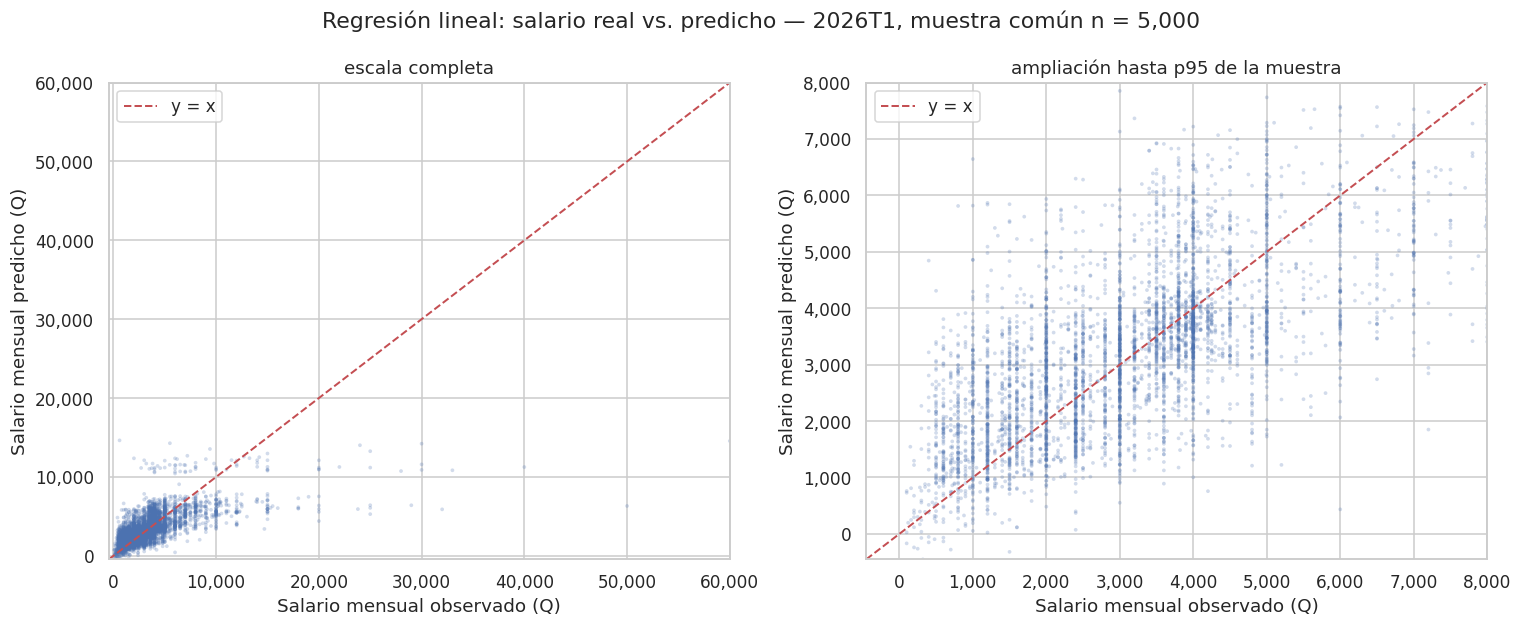

La mayor concentración de observaciones está entre p25 y p75 del salario observado (Q2,000.00 a Q4,080.00). Con la regresión lineal, 37.8% de los registros de 2026T1 tiene una predicción a menos de 20% del salario observado. El error medio es -Q828.73 hasta p25 (sobreestimación), -Q82.11 entre p50 y p75 (sobreestimación), Q4,091.72 entre p95 y p99 y Q14,285.39 por encima de p99 (subestimación). El patrón es de regresión hacia el centro: los salarios bajos quedan por encima de la línea y = x (sobreestimados) y los altos por debajo (subestimados). La dispersión alrededor de la diagonal crece con el salario: el RMSE pasa de Q1,333.76 hasta p25 a Q16,134.88 sobre p99.

In [39]:
fig_real_pred("lr")
md(TX.interp_scatter(R7, "lr"))

### 13.2 Salario real frente a salario predicho — Random Forest

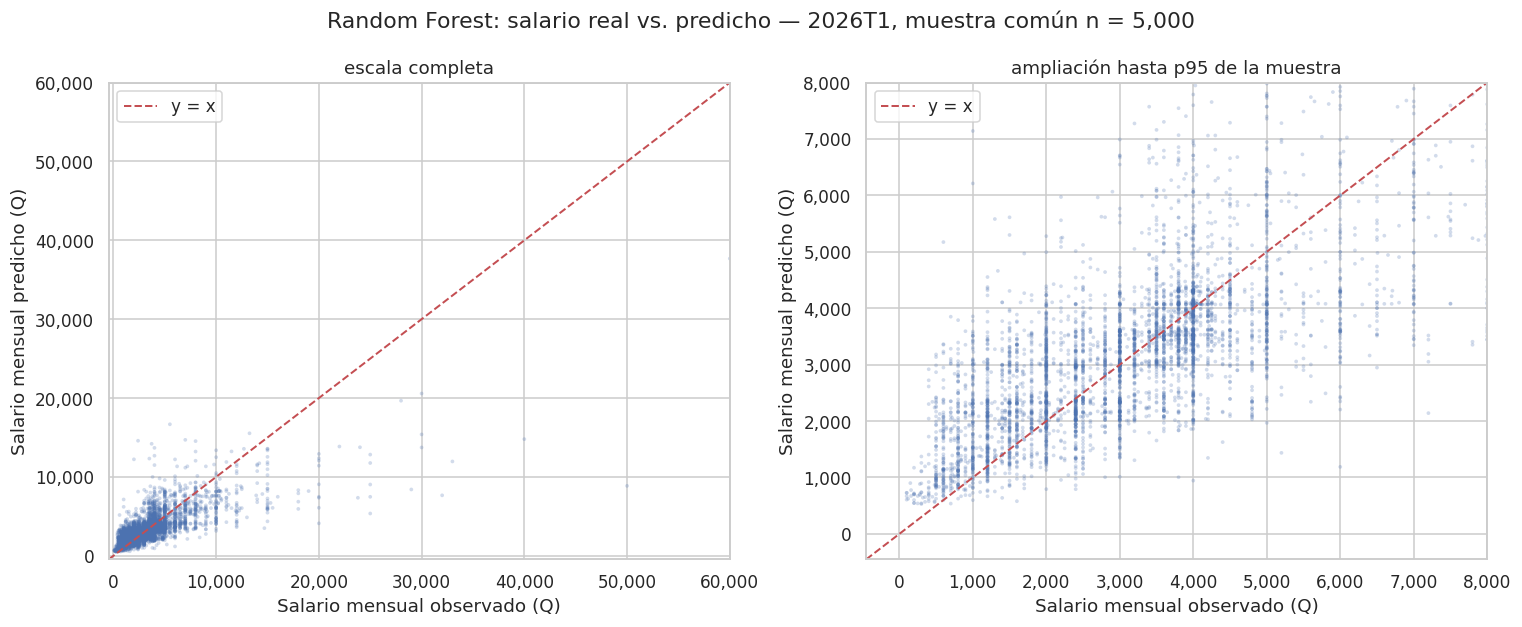

La mayor concentración de observaciones está entre p25 y p75 del salario observado (Q2,000.00 a Q4,080.00). Con Random Forest, 44.0% de los registros de 2026T1 tiene una predicción a menos de 20% del salario observado. El error medio es -Q769.94 hasta p25 (sobreestimación), -Q31.83 entre p50 y p75 (sobreestimación), Q3,490.62 entre p95 y p99 y Q12,292.47 por encima de p99 (subestimación). El patrón es de regresión hacia el centro: los salarios bajos quedan por encima de la línea y = x (sobreestimados) y los altos por debajo (subestimados). La dispersión alrededor de la diagonal crece con el salario: el RMSE pasa de Q1,146.07 hasta p25 a Q13,870.43 sobre p99.

In [40]:
fig_real_pred("rf")
md(TX.interp_scatter(R7, "rf"))

### 13.3 Residuos frente al salario predicho — regresión lineal

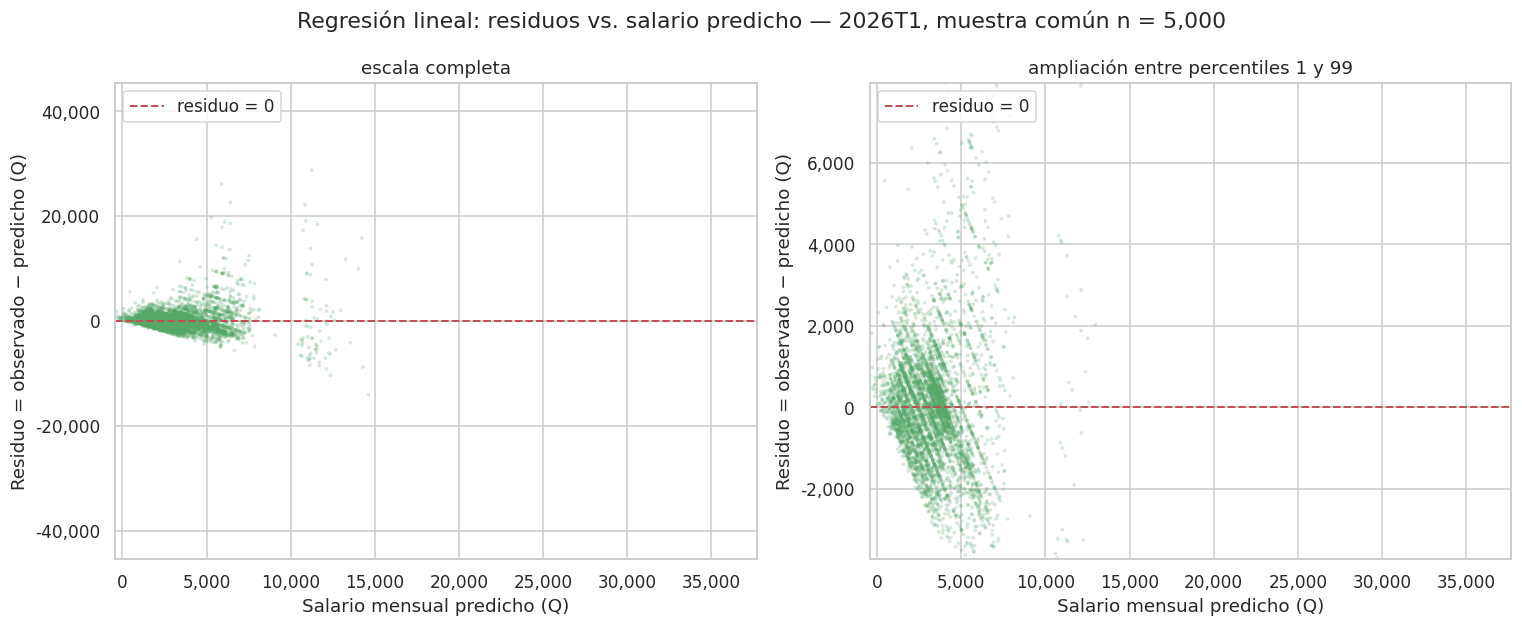

48.9% de los residuos es positivo (subestimación) y su coeficiente de asimetría es 4.71, con una cola larga hacia valores positivos: los errores más grandes corresponden a salarios observados muy superiores a la predicción. Por terciles del salario predicho, la desviación estándar del residuo pasa de Q997.54 en el tercil bajo a Q3,355.61 en el alto (3.4 veces), lo que describe heterocedasticidad: la dispersión crece con el nivel predicho. El error medio por tercil es Q189.63, -Q7.12 y Q179.13. Los percentiles 1 y 99 del residuo son -Q3,752.72 y Q7,892.62, y el máximo llega a Q45,441.47; estos valores extremos se conservan en el panel a escala completa. En conjunto, el error medio es Q120.55, es decir, subestimación promedio.

In [41]:
fig_residuos("lr")
md(TX.interp_residuos(R7, "lr"))

### 13.4 Residuos frente al salario predicho — Random Forest

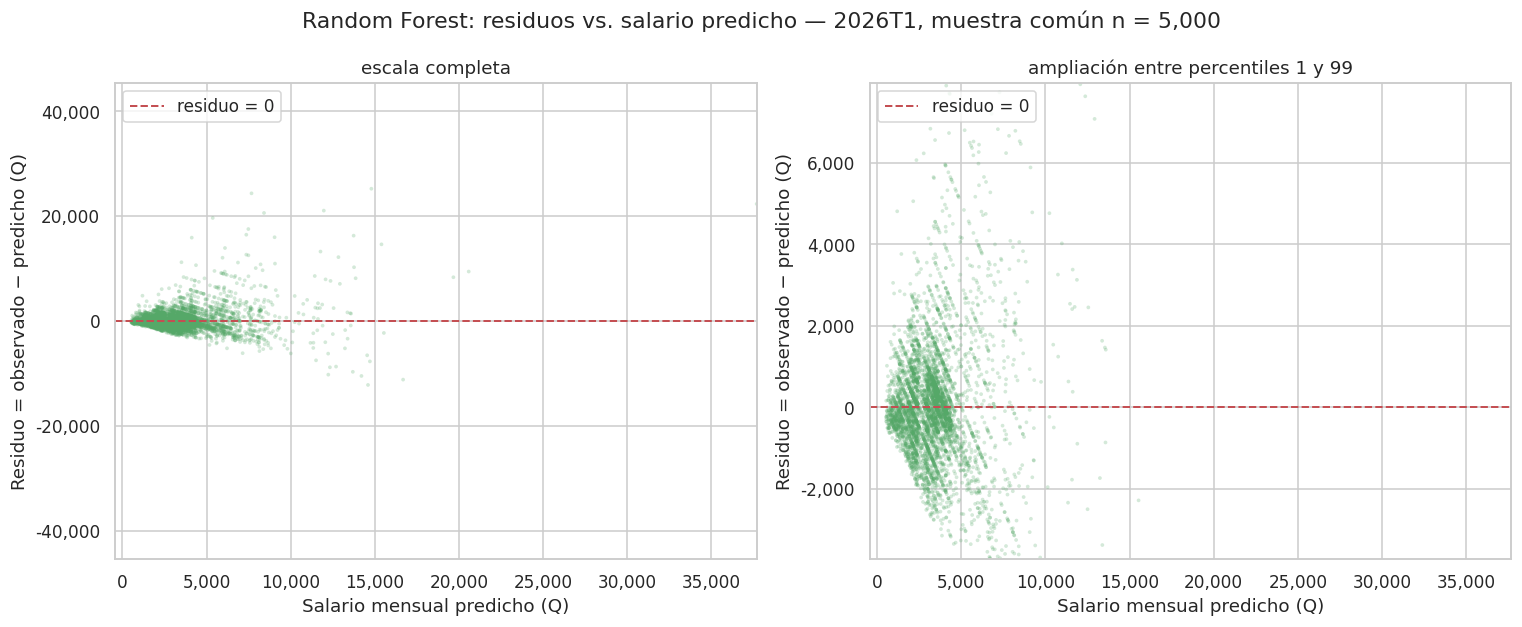

47.4% de los residuos es positivo (subestimación) y su coeficiente de asimetría es 3.96, con una cola larga hacia valores positivos: los errores más grandes corresponden a salarios observados muy superiores a la predicción. Por terciles del salario predicho, la desviación estándar del residuo pasa de Q893.21 en el tercil bajo a Q2,982.78 en el alto (3.3 veces), lo que describe heterocedasticidad: la dispersión crece con el nivel predicho. El error medio por tercil es Q34.06, Q45.96 y Q245.19. Los percentiles 1 y 99 del residuo son -Q3,604.45 y Q6,973.89, y el máximo llega a Q41,132.47; estos valores extremos se conservan en el panel a escala completa. En conjunto, el error medio es Q108.40, es decir, subestimación promedio.

In [42]:
fig_residuos("rf")
md(TX.interp_residuos(R7, "rf"))

## 14. Error por nivel educativo

Calculado con todos los registros de 2026T1. Orden: nivel educativo ascendente. ME = error medio del residuo.

,grupo,n,salario_mediano,MAE_lr,ME_lr,MAE_rf,ME_rf
0,0 Ninguno,1016,"1,680.00",823.51,109.34,653.56,-48.78
1,1 Preprimaria,80,"2,400.00",735.21,88.76,605.74,-64.17
2,2 Primaria,3957,"2,400.00",870.04,54.55,758.21,48.83
3,3 Básico,2164,"3,000.00",894.45,127.77,830.72,153.64
4,4 Diversificado,4117,"3,800.00","1,109.31",103.98,"1,020.65",118.41
5,5 Superior,1729,"5,000.00","2,566.37",295.52,"2,267.15",274.28
6,6 Maestría,183,"10,000.00","5,552.87",-131.48,"4,614.84",-309.69
7,7 Doctorado,12,"18,500.00","12,919.31","6,062.73","11,182.40","5,090.55"


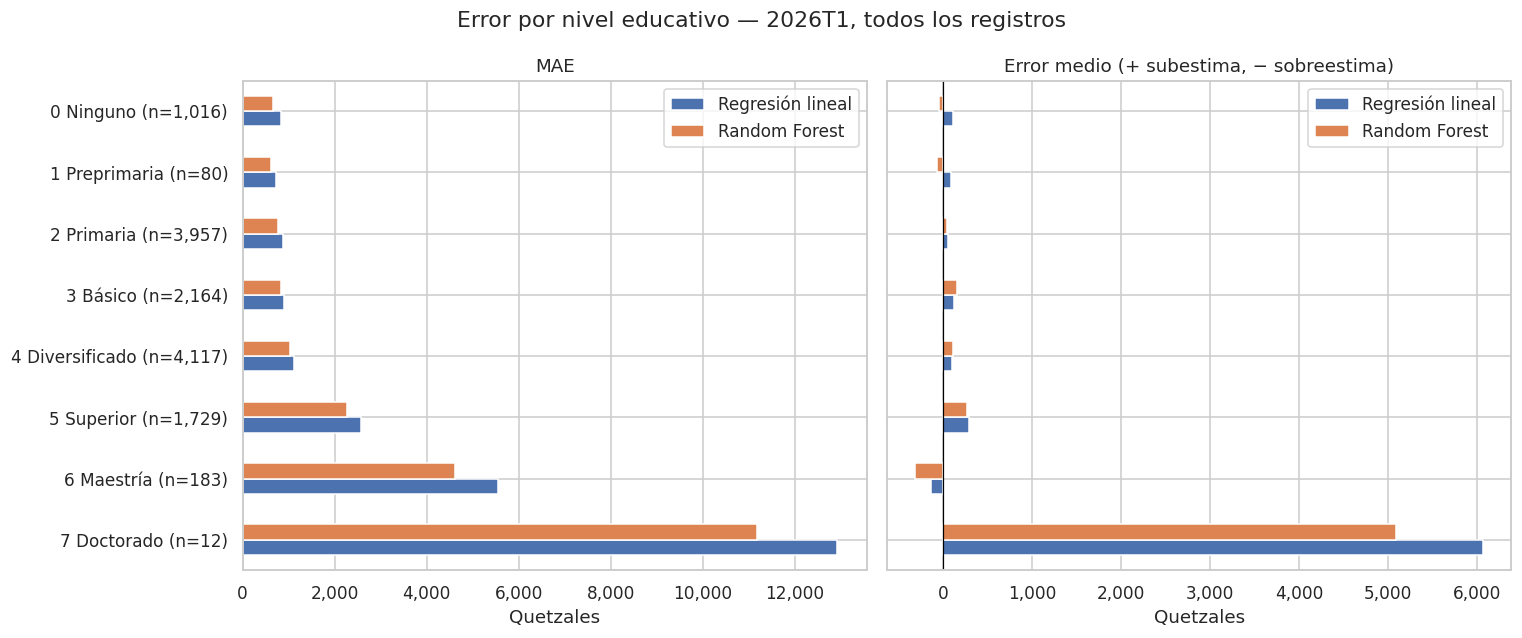

Con la regresión lineal, entre las categorías de nivel educativo con al menos 133 registros, el mayor MAE está en 6 Maestría (Q5,552.87, n = 183) y el menor en 0 Ninguno (Q823.51, n = 1,016), una razón de 6.7 veces, diferencia materialmente importante. 5 Superior concentra 42.3% del error cuadrático con 13.0% de los registros. Hay subestimación promedio en 0 Ninguno, 1 Preprimaria, 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior y 7 Doctorado y sobreestimación promedio en 6 Maestría.

Con Random Forest, entre las categorías de nivel educativo con al menos 133 registros, el mayor MAE está en 6 Maestría (Q4,614.84, n = 183) y el menor en 0 Ninguno (Q653.56, n = 1,016), una razón de 7.1 veces, diferencia materialmente importante. 5 Superior concentra 42.5% del error cuadrático con 13.0% de los registros. Hay subestimación promedio en 2 Primaria, 3 Básico, 4 Diversificado, 5 Superior y 7 Doctorado y sobreestimación promedio en 0 Ninguno, 1 Preprimaria y 6 Maestría.

Entre categorías, la correlación entre el salario mediano del grupo y el MAE de Random Forest es 0.99: el error absoluto tiende a ser mayor donde los salarios son más altos y más dispersos.

Las categorías 1 Preprimaria (n = 80) y 7 Doctorado (n = 12) tienen menos de 133 registros; sus métricas son inestables y se interpretan con precaución.

In [43]:
COLS_GRUPO = ["grupo", "n", "salario_mediano", "MAE_lr", "ME_lr", "MAE_rf", "ME_rf"]
educ = por_grupo(F.col("nivel_educativo"))
educ = educ.set_index("grupo").reindex([g for g in ORDEN_EDU if g in set(educ["grupo"])]).reset_index()
R7["educ"] = registros(educ)
educ.to_csv(RES_DIR / "error_nivel_educativo.csv", index=False)
display(educ[COLS_GRUPO])
fig_grupo(educ, "error_nivel_educativo", "Error por nivel educativo — 2026T1, todos los registros")
md(TX.interp_grupo(R7, "educ", "nivel educativo"))

## 15. Error por dominio

Calculado con todos los registros de 2026T1.

,grupo,n,salario_mediano,MAE_lr,ME_lr,MAE_rf,ME_rf
0,Urbano Metropolitano,5632,"3,900.00","1,446.09",136.04,"1,315.04",171.27
1,Resto Urbano,4846,"3,000.00","1,189.65",134.28,"1,041.92",91.93
2,Rural Nacional,2780,"2,160.00",913.64,65.24,775.40,9.74


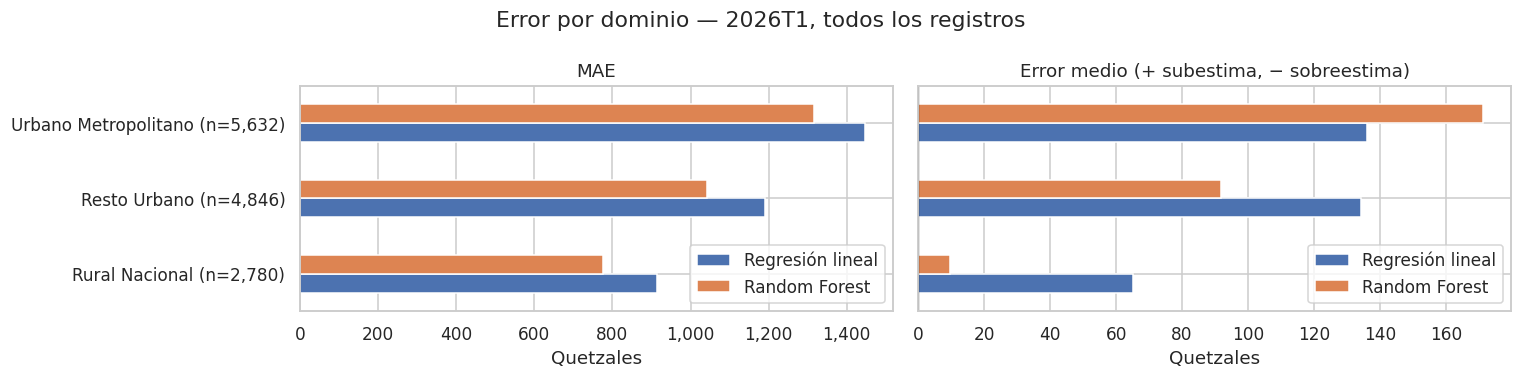

Con la regresión lineal, entre las categorías de dominio con al menos 133 registros, el mayor MAE está en Urbano Metropolitano (Q1,446.09, n = 5,632) y el menor en Rural Nacional (Q913.64, n = 2,780), una razón de 1.6 veces, diferencia materialmente importante. Urbano Metropolitano concentra 66.9% del error cuadrático con 42.5% de los registros. Todas las categorías tienen error medio positivo, es decir, subestimación promedio en Urbano Metropolitano, Resto Urbano y Rural Nacional.

Con Random Forest, entre las categorías de dominio con al menos 133 registros, el mayor MAE está en Urbano Metropolitano (Q1,315.04, n = 5,632) y el menor en Rural Nacional (Q775.40, n = 2,780), una razón de 1.7 veces, diferencia materialmente importante. Urbano Metropolitano concentra 67.9% del error cuadrático con 42.5% de los registros. Todas las categorías tienen error medio positivo, es decir, subestimación promedio en Urbano Metropolitano, Resto Urbano y Rural Nacional.

Entre categorías, la correlación entre el salario mediano del grupo y el MAE de Random Forest es 1.00: el error absoluto tiende a ser mayor donde los salarios son más altos y más dispersos.

Todas las categorías superan 133 registros, por lo que las comparaciones tienen un tamaño de grupo razonable.

In [44]:
dominio = por_grupo(F.col("dominio"))
dominio = dominio.set_index("grupo").reindex([g for g in ORDEN_DOM if g in set(dominio["grupo"])]).reset_index()
R7["dominio"] = registros(dominio)
dominio.to_csv(RES_DIR / "error_dominio.csv", index=False)
display(dominio[COLS_GRUPO])
fig_grupo(dominio, "error_dominio", "Error por dominio — 2026T1, todos los registros")
md(TX.interp_grupo(R7, "dominio", "dominio"))

## 16. Análisis por percentiles de salario

Percentiles exactos de `salario_mensual` en 2026T1 calculados con Spark. Las bandas usan todos los registros; `pct_SSE` es la proporción del error cuadrático total que aporta cada banda.

,p25,p50,p75,p95,p99
0,"2,000.00","3,200.00","4,080.00","8,000.00","15,000.00"


grupo,n,salario_mediano,MAE_lr,RMSE_lr,ME_lr,MAE_rf,RMSE_rf,ME_rf,pct_n,pct_SSE_lr,pct_SSE_rf
1. hasta p25,4032,"1,200.00",998.39,"1,333.76",-828.73,853.23,"1,146.07",-769.94,30.4%,11.6%,10.5%
2. p25–p50,2715,"2,800.00",851.68,"1,158.07",-161.09,675.47,979.55,-156.04,20.5%,5.9%,5.2%
3. p50–p75,3200,"3,800.00",832.90,"1,207.89",-82.11,744.05,"1,196.24",-31.83,24.1%,7.5%,9.1%
4. p75–p95,2668,"5,000.00","1,381.46","1,760.40",753.32,"1,381.43","1,772.32",734.62,20.1%,13.3%,16.6%
5. p95–p99,545,"10,000.00","4,331.28","4,847.80","4,091.72","3,790.20","4,418.94","3,490.62",4.1%,20.6%,21.1%
6. sobre p99,98,"20,000.00","14,285.39","16,134.88","14,285.39","12,292.47","13,870.43","12,292.47",0.7%,41.1%,37.4%


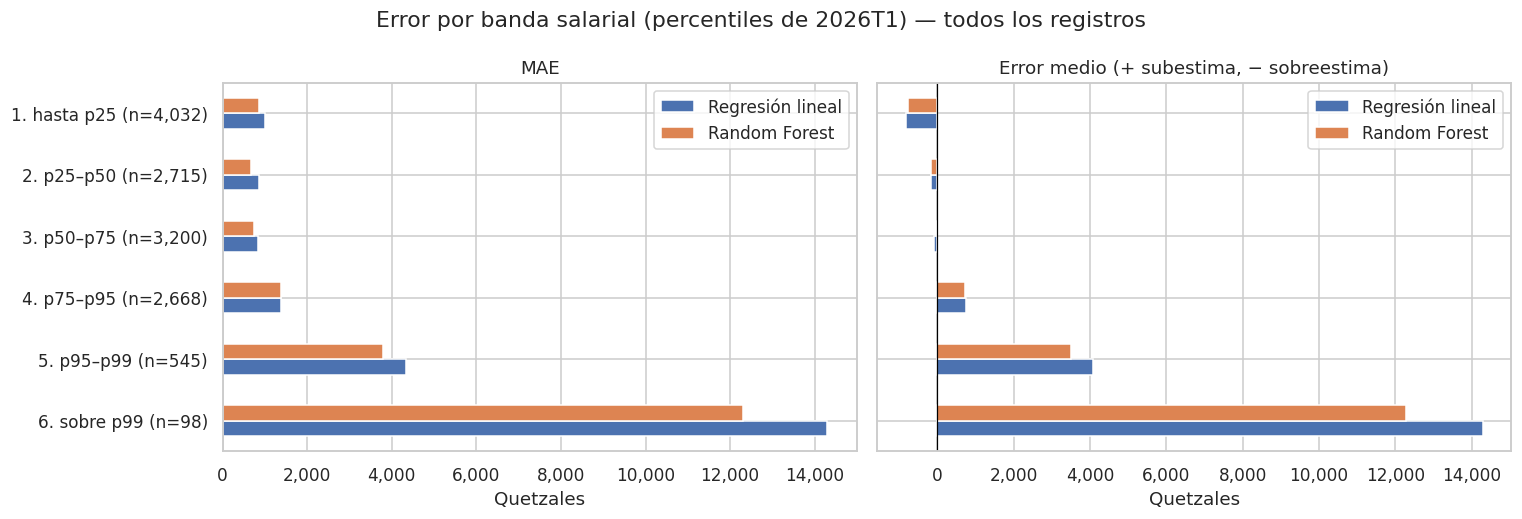

Los percentiles del salario de 2026T1 son p25 = Q2,000.00, p50 = Q3,200.00, p75 = Q4,080.00, p95 = Q8,000.00 y p99 = Q15,000.00; las bandas se construyen con esos cortes y usan todos los registros.

Con la regresión lineal el MAE aumenta de Q998.39 hasta p25 a Q14,285.39 por encima de p99. El error medio es Q4,091.72 entre p95 y p99 y Q14,285.39 sobre p99, es decir, subestimación en la cola extrema. Los registros sobre p95 son 4.8% de la prueba pero aportan 61.7% del error cuadrático total, por lo que los extremos elevan el RMSE global muy por encima del MAE.

Con Random Forest el MAE aumenta de Q853.23 hasta p25 a Q12,292.47 por encima de p99. El error medio es Q3,490.62 entre p95 y p99 y Q12,292.47 sobre p99, es decir, subestimación en la cola extrema. Los registros sobre p95 son 4.8% de la prueba pero aportan 58.6% del error cuadrático total, por lo que los extremos elevan el RMSE global muy por encima del MAE.

Tanto hasta p95 como sobre p95 el menor error absoluto corresponde a Random Forest (MAE de Q898.99 y Q5,086.04, frente a Q1,005.85 y Q5,848.39 de la regresión lineal).

Ninguno de los dos modelos corrige la subestimación de la cola alta; esta se conserva completa en todas las métricas, porque eliminarla reduciría artificialmente el error.

In [45]:
display(pd.DataFrame([R7["percentiles"]]))
bandas.to_csv(RES_DIR / "error_percentiles.csv", index=False)
display(bandas[["grupo", "n", "salario_mediano", "MAE_lr", "RMSE_lr", "ME_lr", "MAE_rf", "RMSE_rf", "ME_rf",
                "pct_n", "pct_SSE_lr", "pct_SSE_rf"]]
        .style.format({c: "{:.1%}" for c in ("pct_n", "pct_SSE_lr", "pct_SSE_rf")} |
                      {c: "{:,.2f}" for c in ("salario_mediano", "MAE_lr", "RMSE_lr", "ME_lr", "MAE_rf", "RMSE_rf", "ME_rf")})
        .hide(axis="index"))
fig_grupo(bandas, "error_percentiles", "Error por banda salarial (percentiles de 2026T1) — todos los registros")
md(TX.interp_bandas(R7))

## 17. Comparación validación (2025T4) vs. prueba (2026T1)

In [46]:
vt = pd.DataFrame([{"Modelo": ETQ[k],
                    **{f"{m} val 2025T4": R7["metricas_val"][k][m] for m in ("MAE", "RMSE", "R2")},
                    **{f"{m} prueba 2026T1": R7["metricas_test"][k][m] for m in ("MAE", "RMSE", "R2")}} for k in ("lr", "rf")])
vt.to_csv(RES_DIR / "validacion_vs_prueba.csv", index=False)
display(vt.style.format({c: ("{:.4f}" if "R2" in c else "{:,.2f}") for c in vt.columns if c != "Modelo"}).hide(axis="index"))
md(TX.interp_val_test(R7))

Modelo,MAE val 2025T4,RMSE val 2025T4,R2 val 2025T4,MAE prueba 2026T1,RMSE prueba 2026T1,R2 prueba 2026T1
Regresión lineal,"1,210.14","2,186.42",0.4257,"1,240.71","2,163.75",0.4307
Random Forest,"1,074.70","1,980.14",0.5289,"1,102.05","1,948.91",0.5382


La regresión lineal: MAE de Q1,210.14 a Q1,240.71 (+2.5%), RMSE de Q2,186.42 a Q2,163.75 (-1.0%) y R² de 0.426 a 0.431. Random Forest: MAE de Q1,074.70 a Q1,102.05 (+2.5%), RMSE de Q1,980.14 a Q1,948.91 (-1.6%) y R² de 0.529 a 0.538.

Los cambios son pequeños (menos de 10% en RMSE y menos de 0.05 en R²) en ambos modelos, lo que indica un desempeño temporalmente estable entre 2025T4 y 2026T1.

Entre 2025T4 y 2026T1 la mediana salarial cambia +0.0% y la media +0.6%. Un nivel salarial algo mayor en 2026 puede acompañar un MAE mayor, mientras que el RMSE depende sobre todo de cuántos salarios extremos contiene cada trimestre; la comparación es descriptiva.

El diseño es longitudinal: una fracción de los individuos de 2026T1 probablemente también aparece en 2025, por lo que la prueba no es completamente independiente del entrenamiento y la estabilidad observada puede ser optimista. Además, la capacidad predictiva no implica causalidad: los modelos capturan asociaciones observadas, no el efecto de modificar un predictor.

In [47]:
# Los modelos guardados se recargan y reproducen las predicciones
lote = test.orderBy(*CLAVE).limit(500)
for k, ruta, modelo in (("lr", ruta_lr_final, modelo_lr_final), ("rf", ruta_rf_final, modelo_rf_final)):
    a = modelo.transform(lote).select("prediction").toPandas()["prediction"]
    b = PipelineModel.load(str(ruta)).transform(lote).select("prediction").toPandas()["prediction"]
    print(f"{ETQ[k]}: {ruta.relative_to(BASE)} recargado, diferencia máxima = {np.abs(a - b).max():.2e}")
    assert np.allclose(a, b)

Regresión lineal: models/linear_regression_final_2025 recargado, diferencia máxima = 0.00e+00


Random Forest: models/random_forest_final_2025 recargado, diferencia máxima = 0.00e+00


## 18. Discusión final integral

Esta sección conecta los resultados de todo el laboratorio. Las cifras provienen de las tablas calculadas en esta misma ejecución.

In [48]:
exc = []
for fila, nombre in (("Total 2025", "2025"), (PERIODO_TEST, PERIODO_TEST)):
    r = conteo.loc[fila]
    exc.append({"conjunto": nombre, "antes": int(r["antes"]), "despues": int(r["después"]),
                "pasos": {m: int(r[m]) for m in MOTIVOS}})
ap = apariciones.set_index("periodos")["count"]
fac = df25.agg(F.mean("FACTOR"), (F.sum(F.col(LABEL) * F.col("FACTOR")) / F.sum("FACTOR")), F.mean(LABEL)).first()
suma_fac = df25.groupBy("periodo_archivo").agg(F.sum("FACTOR").alias("s")).toPandas()["s"]
R7["poblacion"] = {
    "n_2025": df25.count(), "n_2026": df26.count(), "exclusiones": exc,
    "repetidos": {"ids": int(ap.sum()), "pct_mas_de_uno": float(ap[ap.index > 1].sum() / ap.sum()),
                  "pct_cuatro": float(ap.get(4, 0) / ap.sum())},
    "factor": {"media": fac[0], "media_ponderada": fac[1], "media_no_ponderada": fac[2],
               "suma_min": float(suma_fac.min()), "suma_max": float(suma_fac.max())},
}
R7["eda"] = {
    "trimestres": registros(por_trim.rename_axis("periodo").reset_index()[["periodo", "n", "mediana", "media"]]),
    "educ": registros(med_edu.rename_axis("grupo").reset_index()),
    "cat": registros(med_cat.rename_axis("grupo").reset_index()),
}
nums = [v for v in VARS_NUM if v != LABEL]
R7["corr"] = {"pearson_salario": {v: float(corr_pearson.loc[v, LABEL]) for v in nums},
              "spearman_salario": {v: float(corr_spearman.loc[v, LABEL]) for v in nums},
              "edad_antig": float(corr_pearson.loc["edad", "antiguedad"]),
              "matriz": registros(corr_pearson.rename_axis("variable").reset_index())}
tk = resultados_km[resultados_km["conjunto"] == CONJUNTO_ELEGIDO]
R7["cluster"] = {
    "k": int(K_ELEGIDO), "vars": CONJUNTOS[CONJUNTO_ELEGIDO], "conjunto": CONJUNTO_ELEGIDO,
    "tabla_k": registros(tk[["K", "silueta", "cluster_min_%"]].rename(columns={"cluster_min_%": "cluster_min"})),
    "perfiles": registros(perfil.rename_axis("segmento").reset_index()[["segmento", "n", "%", "edad_media", "antig_media", "horas_media", "salario_mediano*"]]
                          .rename(columns={"%": "pct", "edad_media": "edad", "antig_media": "antiguedad",
                                           "horas_media": "horas", "salario_mediano*": "salario_mediano"})),
}
R7["config"] = {"lr": {k: mejor_lr_cfg[k] for k in ("nombre", "regParam", "elasticNetParam")},
                "rf": {**{k: mejor_rf_cfg[k] for k in ("nombre", "numTrees", "maxDepth")}, "seed": SEED},
                "predictores": PREDICTORES_NUM + PREDICTORES_CAT, "media_train_val": media_train,
                "etapas_lr": [type(s).__name__ for s in modelo_lr_final.stages],
                "etapas_rf": [type(s).__name__ for s in modelo_rf_final.stages]}
R7["grids"] = {"lr": registros(tabla_lr.drop(columns="segundos")), "rf": registros(tabla_rf.drop(columns="segundos"))}
R7["splits"] = registros(splits_tbl)

for titulo, texto in TX.discusion(R7):
    md(f"### {titulo}\n\n{texto}")

with open(RES_DIR / "resumen.json", "w", encoding="utf-8") as fh:
    json.dump(R7, fh, ensure_ascii=False, indent=2, default=lambda o: o.item() if hasattr(o, "item") else str(o))
print(f"Resultados exportados a {(RES_DIR / 'resumen.json').relative_to(BASE)} y figuras a {FIG_DIR.relative_to(BASE)}/")

### Calidad y población

La población analítica está formada por los asalariados ocupados de 15 años o más con salario positivo, antigüedad válida y horas en (0, 168]: 53,025 registros de 2025 (entrenamiento y validación) y 13,258 de 2026T1 (prueba). En 2025, de 203,676 registros originales se excluyen 62,886 por edad < 15 o no válida, 52,568 por no ocupado y 35,197 por no asalariado, y quedan 53,025 (26.0%). En 2026T1, de 49,843 registros originales se excluyen 14,803 por edad < 15 o no válida, 13,306 por no ocupado y 8,476 por no asalariado, y quedan 13,258 (26.6%). Los criterios salario no válido o <= 0, antigüedad no evaluable, antigüedad > edad y horas fuera de (0, 168] no excluyen ningún registro. Las exclusiones delimitan la población de interés, asalariados con salario observado, y el salario nunca se imputa ni se recorta. De 26,709 combinaciones de hogar e individuo en 2025, 57.7% aparece en más de un trimestre y 12.5% en los cuatro, reflejo del diseño longitudinal con rotación de la ENEIC; por eso el número de filas no equivale al número de individuos distintos. FACTOR es el factor de expansión: indica cuántos trabajadores de la población representa cada registro (media de 357.2 en 2025 y suma trimestral entre 4,713,724 y 4,787,795). El salario medio ponderado de 2025 sería Q3,175.58, frente a Q3,421.68 sin ponderar. El análisis principal es no ponderado: describe la muestra analítica y no constituye una estimación oficial para toda Guatemala.

### Exploración salarial

En 2025 el salario mensual tiene media Q3,421.68 y mediana Q3,000.00; la media supera a la mediana en Q421.68 y el coeficiente de asimetría es 6.00, lo que describe una distribución sesgada a la derecha con una cola alta larga (p95 = Q8,000.00, p99 = Q15,000.00, máximo = Q99,000.00). Por nivel educativo, la mediana crece de forma monótona con el nivel, desde Q1,500.00 en 0 Ninguno hasta Q12,000.00 en 7 Doctorado (n = 60). Por categoría ocupacional, la mediana más baja es Q1,000.00 en Del servicio doméstico y la más alta Q5,000.00 en Empleado de gobierno. Entre 2025T1 y 2026T1 la mediana pasa de Q3,000.00 a Q3,200.00 y la media de Q3,315.63 a Q3,565.80 en términos nominales.

### Relaciones numéricas

Las correlaciones de Pearson con el salario mensual en 2025 son antiguedad (r = 0.180), edad (r = 0.147) y horas_semanales (r = 0.076); todas son débiles y la más fuerte es con antiguedad. Con Spearman los valores son antiguedad (0.261), edad (0.153) y horas_semanales (0.143). Edad y antigüedad tienen r = 0.487, la asociación más fuerte de la matriz: los trabajadores de mayor edad tienden a acumular más antigüedad y ambos predictores comparten información. Estas correlaciones solo miden asociación y no indican que una variable cause cambios en el salario.

### Segmentación

La segmentación con KMeans usó edad, antiguedad y horas_semanales estandarizadas con StandardScaler y comparó K = 2 a 5. Las siluetas del conjunto elegido fueron 0.555 (K = 2), 0.472 (K = 3), 0.475 (K = 4) y 0.484 (K = 5). Se eligió K = 5 por tener la mayor silueta entre K ≥ 3 con ningún cluster menor a 10% de los registros (el más pequeño tiene 11.7%) y perfiles interpretables; K = 2 tiene mayor silueta pero es demasiado grueso para describir perfiles. El salario no se incluyó en la segmentación: con el salario en quetzales un cluster se dedica a aislar la cola alta y la silueta baja, y con su logaritmo no hay una ganancia clara; así los perfiles se definen por condiciones laborales y el salario queda como variable descriptiva. Perfiles: C1 Jóvenes en jornada completa (42.8%, edad media 26.3 años, antigüedad media 2.6 años, 47.5 horas semanales, salario mediano Q3,200.00); C2 Jornada parcial (12.3%, edad media 29.7 años, antigüedad media 2.9 años, 19.4 horas semanales, salario mediano Q1,200.00); C3 Jornada extensa (11.7%, edad media 31.1 años, antigüedad media 3.7 años, 80.8 horas semanales, salario mediano Q3,000.00); C4 Adultos con antigüedad corta (20.8%, edad media 50.0 años, antigüedad media 4.2 años, 43.4 horas semanales, salario mediano Q3,200.00); C5 Veteranos de larga antigüedad (12.5%, edad media 50.2 años, antigüedad media 22.5 años, 41.2 horas semanales, salario mediano Q3,800.00). Los segmentos son útiles para describir la población, pero se traslapan y dependen de las variables y del escalamiento elegidos, por lo que son perfiles típicos y no grupos cerrados. La etiqueta de cluster no se usa como predictor: el modelo supervisado se limita a los seis predictores obligatorios.

### Modelado supervisado

El modelo de referencia predice una constante: la media de entrenamiento (Q3,383.12 con 2025T1–T3 para validación y Q3,421.68 con todo 2025 para la prueba). La mejor regresión lineal por RMSE de validación es ridge_suave (regParam = 0.01, elasticNetParam = 0.0) y el mejor Random Forest es rf_t40_d10 (40 árboles, profundidad máxima 10, semilla 42). En validación 2025T4, la regresión lineal obtuvo MAE Q1,210.14, RMSE Q2,186.42 y R² 0.426, y Random Forest MAE Q1,074.70, RMSE Q1,980.14 y R² 0.529. En 2026T1, tras reajustar con todo 2025, los valores son MAE Q1,240.71, RMSE Q2,163.75 y R² 0.431 para la regresión lineal, y MAE Q1,102.05, RMSE Q1,948.91 y R² 0.538 para Random Forest; Random Forest es el algoritmo con menor error en la prueba, coherente con su capacidad de capturar interacciones y no linealidades que el modelo lineal aditivo omite.

### Errores

El mayor MAE de Random Forest por nivel educativo aparece en 6 Maestría (Q4,614.84, n = 183) y por dominio en Urbano Metropolitano (Q1,315.04, n = 5,632). El error crece con el salario: sobre p99 el error medio es Q14,285.39 en la regresión lineal y Q12,292.47 en Random Forest (subestimación en ambos), mientras que hasta p25 es -Q828.73 y -Q769.94. Los registros sobre p95 concentran 58.6% del error cuadrático de Random Forest, de modo que las observaciones extremas determinan buena proporción del RMSE.

### Limitaciones

Los datos son observacionales, por lo que ninguna asociación admite interpretación causal. Algunos individuos se repiten longitudinalmente y las observaciones de periodos distintos pueden ser dependientes, lo que debilita la independencia entre entrenamiento y prueba. El análisis principal es no ponderado y no usa FACTOR, por lo que no representa a la población nacional. Los modelos usan exclusivamente seis predictores (edad, antiguedad, horas_semanales, nivel_educativo, categoria_ocupacional y dominio), de modo que omiten otros determinantes del salario, como ocupación específica o rama de actividad. Finalmente, las predicciones describen salarios asociados a perfiles observados y no deben interpretarse como una recomendación de cuánto debería ganar un trabajador.

### Respuesta a las preguntas centrales

Perfiles identificados: con K = 5 se distinguen C1 Jóvenes en jornada completa, C2 Jornada parcial, C3 Jornada extensa, C4 Adultos con antigüedad corta y C5 Veteranos de larga antigüedad. Se organizan en dos ejes, edad con antigüedad y jornada habitual; C5 Veteranos de larga antigüedad tiene el mayor salario mediano y C2 Jornada parcial el menor.

Capacidad de estimación del salario: con los seis predictores permitidos, Random Forest alcanza en 2026T1 un MAE de Q1,102.05, un RMSE de Q1,948.91 y un R² de 0.538, frente a un MAE de Q1,718.09 y un RMSE de Q2,871.42 del modelo de referencia. La capacidad predictiva es moderada: el modelo reduce claramente el error respecto de la media y es estable en el tiempo, pero pierde precisión en la cola alta, donde los salarios sobre p99 presentan un error medio de Q12,292.47.

Resultados exportados a resultados/resumen.json y figuras a figures/
